# Sovereign Dialect-Bridge: Dataset Preparation Pipeline v4

**Target**: 10,000+ samples dari 7 sumber data

| Sumber | Estimasi |
|--------|----------|
| Synthetic multi-style (5 gaya × 15 topik × 12 dialek × 3) | ~2,700 |
| Hand-crafted (kualitas tinggi) | ~45 |
| NusaCrowd/NusaX-Senti (11 bahasa × 3 split × 150) | ~4,950 |
| IndoSum / id_liputan6 (fallback) | ~500–1000 |
| Wikipedia Indonesian 🆕 | ~400 |
| nusa_kalimat (kalimat paralel dialek) 🆕 | ~400–560 |
| id_newspapers_2018 🆕 | ~400 |


## Cell 1 · Environment Check & Smart Install

In [1]:
import importlib
import subprocess
import sys

REQUIRED = {
    "datasets": "datasets",
    "tqdm": "tqdm",
    "matplotlib": "matplotlib",
}

missing_pkgs = []
for pkg_name, import_name in REQUIRED.items():
    try:
        importlib.import_module(import_name)
        print(f"  ✓ {pkg_name}")
    except ImportError:
        missing_pkgs.append(pkg_name)
        print(f"  ✗ {pkg_name} — akan diinstall")

if missing_pkgs:
    print(f"\nInstalling: {', '.join(missing_pkgs)} ...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q"] + missing_pkgs,
        check=True,
    )
    print("Done. Lanjutkan ke cell berikutnya.")
else:
    print("\nSemua package tersedia ✓")

/opt/homebrew/Caskroom/miniforge/base/envs/ai_core/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  ✓ datasets
  ✓ tqdm
  ✓ matplotlib

Semua package tersedia ✓


## Cell 2 · Imports

In [2]:
import json
import re
import random
import hashlib
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

try:
    from datasets import load_dataset
    HF_OK = True
    print("✓ HuggingFace datasets ready")
except ImportError:
    HF_OK = False
    print("✗ datasets tidak tersedia — sumber eksternal akan di-skip")

print("Imports selesai.")

✓ HuggingFace datasets ready
Imports selesai.


## Cell 3 · Konfigurasi Terpusat

In [3]:
CONFIG = {
    # Paths
    "output_dir": Path("."),

    # Split ratio
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "seed": 42,

    # Synthetic (diturunkan agar tidak terlalu dominan)
    "synthetic_samples_per_combo": 5,
    "synthetic_boost_by_dialect": {
        "Betawi": 2,
        "Melayu": 2,
    },

    # NusaX
    "nusax_samples_per_lang_per_split": 250,
    "skip_nusax_languages": ["ngaju"],

    # IndoSum
    "indosum_samples": 1000,

    # Wikipedia
    "wikipedia_samples": 120,
    "wikipedia_scan_limit": 12000,

    # nusa_kalimat
    "nusa_kalimat_per_lang": 40,

    # id_newspapers
    "newspapers_samples": 120,

    # Kontrol porsi data summarization agar hanya jadi suplemen
    "max_summarization_share": 0.12,
    "max_summarization_per_dialect": 90,

    # Quality filter and auto-relabel
    "enable_noise_filter": True,
    "quality_min_text_length": 20,
    "quality_min_summary_length": 20,
    "quality_min_marker_hits_for_relabel": 2,
    "drop_low_conf_indonesia": True,
    "min_indonesian_word_ratio": 0.08,

    # Rebalancing dialect (set high cap to keep quantity)
    "rebalance_max_per_dialect": 100000,
    "rebalance_indonesia_max": 100000,

    # Rebalancing target agency (disabled; handled in training)
    "rebalance_agency_enabled": False,
    "rebalance_agency_max_per_label": 900,
    "rebalance_agency_min_per_label": 120,
    "rebalance_agency_upsample": False,
    "rebalance_agency_target_total": None,

    # Split strategy
    "use_stratified_split": True,
}

random.seed(CONFIG["seed"])
CONFIG["output_dir"].mkdir(parents=True, exist_ok=True)

print("Config:")
for k, v in CONFIG.items():
    print(f"  {k:35s}: {v}")

Config:
  output_dir                         : .
  train_ratio                        : 0.7
  val_ratio                          : 0.15
  seed                               : 42
  synthetic_samples_per_combo        : 5
  synthetic_boost_by_dialect         : {'Betawi': 2, 'Melayu': 2}
  nusax_samples_per_lang_per_split   : 250
  skip_nusax_languages               : ['ngaju']
  indosum_samples                    : 1000
  wikipedia_samples                  : 120
  wikipedia_scan_limit               : 12000
  nusa_kalimat_per_lang              : 40
  newspapers_samples                 : 120
  max_summarization_share            : 0.12
  max_summarization_per_dialect      : 90
  enable_noise_filter                : True
  quality_min_text_length            : 20
  quality_min_summary_length         : 20
  quality_min_marker_hits_for_relabel: 2
  drop_low_conf_indonesia            : True
  min_indonesian_word_ratio          : 0.08
  rebalance_max_per_dialect          : 100000
  rebalance_indon

## Cell 4 · PII Redaction & Schema Helper

In [4]:
PII_PATTERNS = [
    (r"\b\d{16}\b",                                       "[NIK]"),
    (r"\bNIK\s*:?\s*\d{10,16}",                           "[NIK]"),
    (r"(\+62|62|0)\d{9,12}",                              "[PHONE]"),
    (r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}", "[EMAIL]"),
    (r"\b(Jl\.|Jalan)\s+[A-Z][a-zA-Z\s]+No\.?\s*\d+",   "[ADDR]"),
]


def redact_pii(text: str) -> str:
    for pat, rep in PII_PATTERNS:
        text = re.sub(pat, rep, text)
    return text


def make_record(
    dialect: str,
    raw_text: str,
    summary: str,
    urgency_score: float,
    target_agency: str,
    reasoning: str,
) -> dict:
    """Buat satu record — SELALU 6 field lengkap, PII sudah di-redact."""
    return {
        "raw_text":      redact_pii(str(raw_text).strip()),
        "dialect":       str(dialect).strip(),
        "summary":       str(summary).strip(),
        "urgency_score": round(max(0.0, min(1.0, float(urgency_score))), 2),
        "target_agency": str(target_agency).strip(),
        "reasoning":     str(reasoning).strip(),
    }


# Verifikasi make_record selalu menghasilkan 6 field
test_r = make_record("Jawa", "Test teks.", "Ringkasan.", 0.75, "Dinas PU", "Alasan.")
assert set(test_r.keys()) == {"raw_text", "dialect", "summary", "urgency_score", "target_agency", "reasoning"}
print("make_record() OK — selalu 6 field ✓")

make_record() OK — selalu 6 field ✓


## Cell 5 · Topic Metadata (15 Topik)

In [5]:
ALL_DIALECTS = [
    "Jawa", "Sunda", "Betawi", "Minang", "Batak",
    "Melayu", "Bali", "Bugis", "Madura", "Banjar", "Aceh", "Indonesia",
]

TOPIC_META = {
    "jalan_rusak":    {"agency": "Dinas Pekerjaan Umum",             "urgency": (0.65, 0.90),
                       "summary": "Warga melaporkan kerusakan jalan yang membahayakan keselamatan.",
                       "reasoning": "Jalan rusak menimbulkan risiko kecelakaan tinggi. Perbaikan segera diperlukan."},
    "banjir":         {"agency": "BPBD / Dinas Pekerjaan Umum",      "urgency": (0.75, 0.98),
                       "summary": "Warga melaporkan banjir yang melanda permukiman.",
                       "reasoning": "Banjir mengancam jiwa dan harta benda. Respons darurat BPBD mendesak."},
    "air_bersih":     {"agency": "PDAM / Dinas Air Minum",            "urgency": (0.70, 0.90),
                       "summary": "Warga melaporkan gangguan pasokan air bersih.",
                       "reasoning": "Air bersih vital. Gangguan berhari-hari meningkatkan risiko penyakit."},
    "sampah":         {"agency": "Dinas Lingkungan Hidup",            "urgency": (0.40, 0.65),
                       "summary": "Warga melaporkan penumpukan sampah yang mengganggu kesehatan.",
                       "reasoning": "Sampah menumpuk jadi sumber penyakit. Jadwal pengangkutan harus diperbaiki."},
    "listrik":        {"agency": "PLN",                               "urgency": (0.55, 0.75),
                       "summary": "Warga melaporkan pemadaman listrik berulang.",
                       "reasoning": "Pemadaman berulang hambat kegiatan warga dan ekonomi lokal."},
    "sekolah":        {"agency": "Dinas Pendidikan",                  "urgency": (0.60, 0.85),
                       "summary": "Warga melaporkan kerusakan fasilitas sekolah.",
                       "reasoning": "Gedung rusak ancam keselamatan siswa dan hambat KBM."},
    "puskesmas":      {"agency": "Dinas Kesehatan",                   "urgency": (0.55, 0.80),
                       "summary": "Warga melaporkan keterbatasan layanan puskesmas.",
                       "reasoning": "Layanan kesehatan dasar tidak memadai, ancam kesehatan warga rentan."},
    "jembatan":       {"agency": "Dinas Pekerjaan Umum",             "urgency": (0.80, 0.95),
                       "summary": "Warga melaporkan kondisi jembatan rusak atau rawan runtuh.",
                       "reasoning": "Jembatan rapuh berisiko ambruk dan mengancam nyawa. Inspeksi darurat mendesak."},
    "longsor":        {"agency": "BPBD / Dinas Pekerjaan Umum",      "urgency": (0.85, 0.98),
                       "summary": "Warga melaporkan longsor yang menutup akses dan mengancam permukiman.",
                       "reasoning": "Longsor adalah darurat bencana. Evakuasi dan pembukaan akses mendesak."},
    "limbah":         {"agency": "Dinas Lingkungan Hidup / KLHK",    "urgency": (0.70, 0.88),
                       "summary": "Warga melaporkan pencemaran lingkungan akibat limbah.",
                       "reasoning": "Pencemaran limbah ancam kesehatan warga dan ekosistem."},
    "bansos":         {"agency": "Dinas Sosial",                      "urgency": (0.40, 0.60),
                       "summary": "Warga melaporkan distribusi bansos tidak tepat sasaran.",
                       "reasoning": "Salah sasaran bansos merugikan warga miskin yang berhak."},
    "administrasi":   {"agency": "Disdukcapil / Kelurahan",           "urgency": (0.25, 0.45),
                       "summary": "Warga melaporkan kesulitan pengurusan dokumen administrasi.",
                       "reasoning": "Administrasi lambat hambat hak sipil warga. Perlu digitalisasi."},
    "transportasi":   {"agency": "Dinas Perhubungan",                 "urgency": (0.35, 0.55),
                       "summary": "Warga melaporkan keterbatasan sarana transportasi umum.",
                       "reasoning": "Minimnya angkutan tingkatkan biaya warga dan hambat akses ekonomi."},
    "keamanan":       {"agency": "Polri / Satpol PP",                 "urgency": (0.60, 0.80),
                       "summary": "Warga melaporkan gangguan keamanan dan ketertiban.",
                       "reasoning": "Gangguan keamanan ancam keselamatan jiwa dan harta. Patroli perlu ditingkatkan."},
    "gizi_stunting":  {"agency": "Dinas Kesehatan / BKKBN",          "urgency": (0.65, 0.82),
                       "summary": "Warga melaporkan tingginya kasus stunting dan posyandu tidak aktif.",
                       "reasoning": "Stunting berdampak permanen. Intervensi gizi dan reaktivasi posyandu mendesak."},
}

print(f"Topics loaded: {len(TOPIC_META)}")
print(f"Dialects     : {len(ALL_DIALECTS)} — {', '.join(ALL_DIALECTS)}")

Topics loaded: 15
Dialects     : 12 — Jawa, Sunda, Betawi, Minang, Batak, Melayu, Bali, Bugis, Madura, Banjar, Aceh, Indonesia


In [6]:
# Quality utilities: noise filtering and dialect auto-relabel
DIALECT_MARKERS = {
    "Jawa": ["kulo", "nyuwun", "mboten", "sampun", "mugi", "dalan", "teng"],
    "Sunda": ["punten", "abdi", "teu", "tos", "wilujeng", "margi"],
    "Betawi": ["kagak", "bang", "ane", "udah", "ngangkut", "bau nye"],
    "Minang": ["ambo", "indak", "urang", "kampuang", "bana", "lah"],
    "Batak": ["horas", "adong", "ndang", "huta", "ma", "do"],
    "Melayu": ["tak", "dah", "kampung", "paip", "nak", "lah"],
    "Bali": ["inggih", "tiang", "ring", "nenten", "toya", "sampun"],
    "Bugis": ["pakkitae", "ri", "ana-ana", "dalangnge", "uwae"],
    "Madura": ["kaule", "ta'", "dalan", "sakola", "engkok", "bik"],
    "Banjar": ["ulun", "banar", "kada", "handak", "runtah", "ai"],
    "Aceh": ["lahe", "hana", "aneuk", "ureung", "krueng", "nyoe"],
}

CIVIC_COMPLAINT_KEYWORDS = [
    "jalan", "jembatan", "banjir", "longsor", "air", "pdam", "sampah", "limbah",
    "listrik", "puskesmas", "sekolah", "dokter", "transportasi", "angkutan",
    "administrasi", "ktp", "keamanan", "maling", "stunting", "bansos",
    "warga", "lapor", "pengaduan", "darurat", "tolong", "mohon",
]

NON_CIVIC_NOISE_KEYWORDS = [
    "restoran", "kafe", "cafe", "menu", "makanan", "hotel", "wisata", "gofood",
    "tokopedia", "produk", "lotion", "apple", "asian games", "karate", "liga",
    "sepak bola", "kuliner", "film", "musik", "pacar", "nongkrong",
]

INDONESIAN_COMMON_WORDS = {
    "yang", "dan", "di", "ke", "dari", "untuk", "dengan", "tidak", "sudah", "kami",
    "warga", "jalan", "air", "sampah", "listrik", "lapor", "mohon", "tolong", "karena",
    "ada", "ini", "itu", "pada", "agar", "lebih", "segera", "dinas", "kelurahan",
}


def normalize_text_for_lang(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text


def score_dialect_markers(text: str) -> dict:
    txt = normalize_text_for_lang(text)
    scores = {"Indonesia": 0}
    for dialect, markers in DIALECT_MARKERS.items():
        score = 0
        for marker in markers:
            pattern = rf"\b{re.escape(marker)}\b"
            if re.search(pattern, txt):
                score += 1
        scores[dialect] = score
    return scores


def indonesian_word_ratio(text: str) -> float:
    tokens = normalize_text_for_lang(text).split()
    if not tokens:
        return 0.0
    hit = sum(1 for t in tokens if t in INDONESIAN_COMMON_WORDS)
    return hit / len(tokens)


def relabel_dialect_from_text(text: str, current_label: str, min_hits: int = 2):
    scores = score_dialect_markers(text)
    current = current_label if current_label in ALL_DIALECTS else "Indonesia"

    best_label = max(scores, key=scores.get)
    best_score = scores[best_label]
    current_score = scores.get(current, 0)

    # If currently Indonesia, relabel only when another dialect is confidently detected
    if current == "Indonesia":
        if best_label != "Indonesia" and best_score >= min_hits:
            return best_label, best_score, scores
        return "Indonesia", current_score, scores

    # If currently a dialect, keep it unless another dialect is much stronger
    if best_label != current and best_label != "Indonesia" and best_score >= max(min_hits, current_score + 1):
        return best_label, best_score, scores

    return current, current_score, scores


def is_civic_or_complaint_text(text: str) -> bool:
    txt = normalize_text_for_lang(text)
    civic_hits = sum(1 for kw in CIVIC_COMPLAINT_KEYWORDS if kw in txt)
    noise_hits = sum(1 for kw in NON_CIVIC_NOISE_KEYWORDS if kw in txt)

    if civic_hits >= 1:
        return True
    if noise_hits >= 1:
        return False
    return any(x in txt for x in ["lapor", "pengaduan", "darurat", "mohon", "tolong", "warga"])


def clean_and_relabel_record(rec: dict, source: str = "unknown"):
    rec = dict(rec)
    rec["raw_text"] = str(rec.get("raw_text", "")).strip()
    rec["summary"] = str(rec.get("summary", "")).strip()
    rec["reasoning"] = str(rec.get("reasoning", "")).strip()

    if len(rec["raw_text"]) < CONFIG.get("quality_min_text_length", 20):
        return None
    if len(rec["summary"]) < CONFIG.get("quality_min_summary_length", 20):
        return None

    if CONFIG.get("enable_noise_filter", True):
        # Gunakan raw_text sebagai sinyal utama agar summary template tidak meloloskan noise.
        if not is_civic_or_complaint_text(rec["raw_text"]):
            return None

    min_hits = CONFIG.get("quality_min_marker_hits_for_relabel", 2)
    merged_for_lang = f"{rec['raw_text']} {rec['summary']}"
    new_label, score, _ = relabel_dialect_from_text(
        merged_for_lang,
        rec.get("dialect", "Indonesia"),
        min_hits=min_hits,
    )
    rec["dialect"] = new_label

    if rec["dialect"] == "Indonesia" and CONFIG.get("drop_low_conf_indonesia", True):
        if score < 1 and indonesian_word_ratio(rec["raw_text"]) < CONFIG.get("min_indonesian_word_ratio", 0.08):
            return None

    return rec


print("Quality utilities ready.")

Quality utilities ready.


## Cell 6 · Dialect Complaint Cores
Setiap entri: `{loc}` akan di-substitusi saat generate.

In [7]:
COMPLAINT_CORES = {
    "Jawa": {
        "jalan_rusak":   ["jalan teng {loc} sampun rusak parah", "dalan teng {loc} bolong-bolong, warga sering celaka"],
        "banjir":        ["banjir teng {loc} mlebet omah warga", "banyu kali mluber ngantos teng {loc}"],
        "air_bersih":    ["banyu PDAM teng {loc} sampun mati pirang dinten", "sumur teng {loc} asat, warga kesulitan"],
        "sampah":        ["sampah numpuk teng {loc} mboten wonten ingkang ngangkut", "TPS teng {loc} sampun blobor"],
        "listrik":       ["listrik teng {loc} mati ping papat saben minggu", "PLN teng {loc} mboten stabil"],
        "sekolah":       ["atap sekolah teng {loc} bocor parah", "gedung SD teng {loc} sampun rusak"],
        "puskesmas":     ["puskesmas teng {loc} kekurangan dokter", "obat teng puskesmas {loc} telas"],
        "jembatan":      ["jembatan teng {loc} retak lan rapuh", "jembatan teng {loc} arep ambruk"],
        "longsor":       ["longsor nutup dalan siji-sijine menyang {loc}", "tanah melorot ngancam omah teng {loc}"],
        "limbah":        ["limbah pabrik mili teng kali {loc}", "kali teng {loc} sampun cemari limbah"],
        "bansos":        ["bantuan sosial teng {loc} mboten merata", "warga mlarat teng {loc} mboten kebagian bansos"],
        "administrasi":  ["ngurus KTP teng {loc} susah sanget", "sertifikat tanah teng {loc} mboten rampung-rampung"],
        "transportasi":  ["angkutan umum teng {loc} langka sanget", "mboten wonten bis menyang {loc}"],
        "keamanan":      ["teng {loc} sering wonten maling", "lampu jalan teng {loc} mati, rawan kejahatan"],
        "gizi_stunting": ["bocah-bocah teng {loc} kathah ingkang stunting", "posyandu teng {loc} mboten aktif"],
    },
    "Sunda": {
        "jalan_rusak":   ["jalan di {loc} tos ruksak pisan", "margi di {loc} loba nu bolong, bahaya pisan"],
        "banjir":        ["banjir bandang ngarugikeun warga di {loc}", "cai walungan meluap ka {loc}"],
        "air_bersih":    ["cai PAM di {loc} tos henteu ngocor", "sumur di {loc} tos saat, warga susah"],
        "sampah":        ["runtah numpuk di {loc} teu aya nu angkut", "TPS di {loc} tos pinuh"],
        "listrik":       ["listrik di {loc} sering pareum", "PLN di {loc} henteu stabil"],
        "sekolah":       ["atap sakola di {loc} bocor, murid basah", "gedung SDN di {loc} tos rapuh"],
        "puskesmas":     ["puskesmas di {loc} teu aya dokter", "obat di puskesmas {loc} tos béak"],
        "jembatan":      ["jembatan di {loc} tos rapuh kacida", "sasak di {loc} rék rubuh"],
        "longsor":       ["longsor nutup jalan hiji-hijina ka {loc}", "taneuh di {loc} urug ngancem imah"],
        "limbah":        ["limbah pabrik ngalir ka walungan {loc}", "cai di {loc} tos karacunan limbah"],
        "bansos":        ["bantuan di {loc} teu merata", "warga miskin di {loc} teu kabagian bansos"],
        "administrasi":  ["ngurus KTP di {loc} riweuh teuing", "perizinan di {loc} teu aya kapastian"],
        "transportasi":  ["angkot di {loc} tos langka pisan", "teu aya kendaraan umum ka {loc}"],
        "keamanan":      ["di {loc} sering aya rampog", "lampu jalan di {loc} padam, karang aman"],
        "gizi_stunting": ["loba budak stunting di {loc}", "posyandu di {loc} teu aktif"],
    },
    "Betawi": {
        "jalan_rusak":   ["jalan di {loc} udeh ancur lebur", "gang di {loc} penuh bolong kagak bisa dibiarin"],
        "banjir":        ["banjir lagi melanda {loc}", "aer masuk ke rumah warga di {loc}"],
        "air_bersih":    ["aer PDAM di {loc} udeh seminggu mati", "sumur di {loc} kering, susah banget"],
        "sampah":        ["sampah numpuk di {loc} kagak diangkut-angkut", "tumpukan sampah di {loc} baunye ke mana-mana"],
        "listrik":       ["listrik di {loc} byar-pet terus sehari bisa 4 kali", "PLN di {loc} kagak stabil"],
        "sekolah":       ["atep sekolahan di {loc} bocor parah", "gedung sekolah di {loc} udeh reyot"],
        "puskesmas":     ["puskesmas di {loc} kagak ada dokternya", "obat di puskesmas {loc} sering abis"],
        "jembatan":      ["jembatan di {loc} udeh retak parah", "titi di {loc} mau roboh"],
        "longsor":       ["tanah longsor nutup jalan ke {loc}", "tanah di {loc} amblas ancurin rumah warga"],
        "limbah":        ["limbah pabrik buang ke kali di {loc}", "kali di {loc} item kaya tinta"],
        "bansos":        ["bansos di {loc} kagak merata", "warga miskin di {loc} kagak dapet bantuan"],
        "administrasi":  ["ngurus KTP di {loc} ribet banget bolak-balik", "urus perizinan di {loc} kagak ada kepastian"],
        "transportasi":  ["angkot di {loc} udeh langka banget", "kagak ada kendaraan umum ke {loc}"],
        "keamanan":      ["di {loc} sering ada jambret", "lampu jalan di {loc} mati berbulan-bulan"],
        "gizi_stunting": ["anak-anak di {loc} banyak yang stunting", "posyandu di {loc} kagak jalan"],
    },
    "Minang": {
        "jalan_rusak":   ["jalan di {loc} lah ancua parah", "jalan di {loc} banyak lubang, bahayo bana"],
        "banjir":        ["banjia gadang melanda {loc}", "aia sungai meluap ka {loc}"],
        "air_bersih":    ["aia barsiah di {loc} indak ado sudah lamo", "sumua di {loc} lah karua"],
        "sampah":        ["sampah manumpuak di {loc} indak diangkut", "tumpukan sampah di {loc} baunyo indak takuek"],
        "listrik":       ["listirik di {loc} sering mati indak tantu", "PLN di {loc} ndak stabil"],
        "sekolah":       ["atap sakolah di {loc} bocoa parah", "gedung sakolah di {loc} lah lapuak"],
        "puskesmas":     ["puskesmas di {loc} kurang dokter", "obat puskesmas di {loc} habis"],
        "jembatan":      ["jambatan di {loc} lah rapuah bana", "jambatan di {loc} mau ambruak"],
        "longsor":       ["tanah longsor nutup jalan satu-satunyo ka {loc}", "tanah di {loc} turun ancam rumah"],
        "limbah":        ["limbah pabrik masu ka batang aia di {loc}", "aia di {loc} lah tercemar limbah"],
        "bansos":        ["bantuan pamerintah indak sampai ka {loc}", "urang miskin di {loc} indak dapek bansos"],
        "administrasi":  ["ngurus surek teng {loc} lamo bana", "perizinan di {loc} indak jaleh"],
        "transportasi":  ["angkutan umum ka {loc} lah langko bana", "indak ado angkutan ka {loc}"],
        "keamanan":      ["di {loc} sering ado maling", "lampu jalan di {loc} mati, indak aman"],
        "gizi_stunting": ["anak-anak di {loc} banyak stunting", "posyandu di {loc} indak aktif"],
    },
    "Batak": {
        "jalan_rusak":   ["jalan di huta {loc} sude rusak do", "dalan di {loc} pe lubang-lubang do"],
        "banjir":        ["banjir magodang melanda {loc}", "aek naluap masuk tu omah di {loc}"],
        "air_bersih":    ["aek ledeng di {loc} ndang adong sudah saminggu on", "sumur di {loc} asat do"],
        "sampah":        ["sampah di {loc} ndang diangkut-angkut", "tumpukan sampah di {loc} mambiar bau"],
        "listrik":       ["listrik di {loc} sering mate tolu hali sada ari", "PLN di {loc} ndang stabil"],
        "sekolah":       ["atap sikola di {loc} bocor do", "gedung sikola di {loc} rusak do"],
        "puskesmas":     ["puskesmas di {loc} kurang obat do", "dokter di puskesmas {loc} ndang adong"],
        "jembatan":      ["jembatan di {loc} rapuh do gabe mago tarsungkup", "jembatan di {loc} harus dipature"],
        "longsor":       ["tanoh longsor nutup dalan sada-sadana tu {loc}", "tanoh di {loc} mego ancam huta"],
        "limbah":        ["limbah pabrik masuk tu aek di {loc}", "aek di {loc} kotor dek limbah do"],
        "bansos":        ["bantuan ndang jumpah tu {loc}", "halak marsak di {loc} ndang dapot bansos"],
        "administrasi":  ["urus surat di {loc} lamana do", "perizinan di {loc} ndang jalehe"],
        "transportasi":  ["angkutan tu {loc} langka do", "ndang adong kendaraan tu {loc}"],
        "keamanan":      ["di {loc} sering adong maling do", "lampu jalan di {loc} mate, rawan kejahatan"],
        "gizi_stunting": ["anak-anak di {loc} banyak stunting do", "posyandu di {loc} ndang aktif"],
    },
    "Melayu": {
        "jalan_rusak":   ["jalan di {loc} dah rosak teruk", "jalan di {loc} berlubang-lubang, bahaya"],
        "banjir":        ["banjir telah melanda {loc}", "air sungai melimpah ke {loc}"],
        "air_bersih":    ["air paip di {loc} tak mengalir sudah seminggu", "perigi di {loc} dah kering"],
        "sampah":        ["sampah bertimbun di {loc} tak diangkut", "tumpukan sampah di {loc} berbau busuk"],
        "listrik":       ["elektrik di {loc} sering padam", "PLN di {loc} tak stabil"],
        "sekolah":       ["bumbung sekolah di {loc} bocor, murid basah", "bangunan sekolah di {loc} dah usang"],
        "puskesmas":     ["klinik di {loc} kekurangan doktor", "ubat di klinik {loc} habis"],
        "jembatan":      ["jambatan di {loc} rapuh, nak roboh", "titi di {loc} dah retak teruk"],
        "longsor":       ["tanah runtuh tutup jalan satu-satunya ke {loc}", "cerun di {loc} mengancam rumah"],
        "limbah":        ["sisa kilang dibuang ke sungai {loc}", "air di {loc} tercemar limbah"],
        "bansos":        ["bantuan tak sampai ke {loc}", "orang miskin di {loc} tak dapat bantuan"],
        "administrasi":  ["urusan surat di {loc} berbelit-belit", "perizinan di {loc} tak ada kepastian"],
        "transportasi":  ["pengangkutan ke {loc} amat kurang", "tak ada kenderaan awam ke {loc}"],
        "keamanan":      ["kecurian sering berlaku di {loc}", "lampu jalan di {loc} mati, tak selamat"],
        "gizi_stunting": ["ramai kanak-kanak stunting di {loc}", "posyandu di {loc} tak berfungsi"],
    },
    "Bali": {
        "jalan_rusak":   ["marga di {loc} sampun rusak pisan", "jalan ring {loc} loba sane bolong"],
        "banjir":        ["blabar ageng melanda {loc}", "tukade meluap ngantos ring {loc}"],
        "air_bersih":    ["toya PAM ring {loc} nenten medal sampun pirang dinten", "yeh ring {loc} sampun telas"],
        "sampah":        ["leluu numpuk ring {loc} nenten kaangkut", "sampah ring {loc} sampun mengganggu"],
        "listrik":       ["listrik ring {loc} sring padem", "PLN ring {loc} nenten stabil"],
        "sekolah":       ["atap sekolah ring {loc} bocor, siswa basah", "gedung sekolah ring {loc} sampun rusak"],
        "puskesmas":     ["puskesmas ring {loc} kekurangan dokter", "obat ring puskesmas {loc} telas"],
        "jembatan":      ["titi ring {loc} sampun rapuh kacida", "jembatan ring {loc} jagi rubuh"],
        "longsor":       ["longsor nutup marga ring {loc}", "taneuh ring {loc} ambruk ngancan imah"],
        "limbah":        ["limbah pabrik ngalir ring tukad {loc}", "yeh ring {loc} sampun tercemar"],
        "bansos":        ["bantuan ring {loc} nenten merata", "krama miskin ring {loc} nenten polih bansos"],
        "administrasi":  ["ngurus surat ring {loc} susah pisan", "perizinan ring {loc} nenten jelas"],
        "transportasi":  ["angkutan ring {loc} langka pisan", "nenten wenten kendaraan ka {loc}"],
        "keamanan":      ["ring {loc} sering wenten maling", "lampu jalan ring {loc} padem, karang aman"],
        "gizi_stunting": ["rare-rare ring {loc} akeh stunting", "posyandu ring {loc} nenten aktif"],
    },
    "Bugis": {
        "jalan_rusak":   ["dalangnge ri {loc} lao ampe rusak pura", "dalan ri {loc} maega lubang-lubang"],
        "banjir":        ["bosi manga masuk ri bola-bola di {loc}", "uwae tassi meluap ri {loc}"],
        "air_bersih":    ["uwae PAM ri {loc} tenna jama sudah barapa esso", "sumure ri {loc} kering"],
        "sampah":        ["runtah numpuk ri {loc} tenna diangkut", "sampah ri {loc} mabbiar bau"],
        "listrik":       ["listrik ri {loc} sering mate", "PLN ri {loc} tenna stabil"],
        "sekolah":       ["atapna sikola ri {loc} bocor purai", "bangunan sikola ri {loc} rusak do"],
        "puskesmas":     ["puskesmasge ri {loc} kurang doktere", "obatna puskesmas ri {loc} bek le"],
        "jembatan":      ["jembatanna ri {loc} roppok purai", "jembatan ri {loc} elo ambruk"],
        "longsor":       ["tanah lari ri {loc} nutup dalan", "tanahe ri {loc} turun merusak bola"],
        "limbah":        ["limbah pabrik masuk ri uwae {loc}", "uwae ri {loc} kotor dek limbah"],
        "bansos":        ["bantuan ri {loc} tenna merata", "tau miskin ri {loc} tenna dapek bansos"],
        "administrasi":  ["urus surat ri {loc} susah purai", "perizinan ri {loc} tenna jelas"],
        "transportasi":  ["angkutan ri {loc} langka purai", "tenna engka kendaraan ri {loc}"],
        "keamanan":      ["ri {loc} sering engka maling", "lampuna ri {loc} mate, rawan kejahatan"],
        "gizi_stunting": ["ana-ana ri {loc} maega stunting", "posyandu ri {loc} tenna aktif"],
    },
    "Madura": {
        "jalan_rusak":   ["jalan e {loc} rusak parah", "dalan e {loc} akeh bolonge"],
        "banjir":        ["banjir e {loc} ngancam warga", "bannye meluap ngantos e {loc}"],
        "air_bersih":    ["ban e {loc} mati barapa ariya", "sumur e {loc} areng"],
        "sampah":        ["sampah numpuk e {loc} ta' diangkut", "runtah e {loc} mengganggu"],
        "listrik":       ["listrik e {loc} carat-padam terus", "PLN e {loc} ta' stabil"],
        "sekolah":       ["atap sakola e {loc} bocor parah", "gedung sakola e {loc} rusak"],
        "puskesmas":     ["puskesmas e {loc} kurang dokter", "obat puskesmas e {loc} abis"],
        "jembatan":      ["jembatan e {loc} rapuh ta' aman", "jembatan e {loc} mau ambruk"],
        "longsor":       ["tanah longsor nutup jalan e {loc}", "tane e {loc} melorot ngancam omah"],
        "limbah":        ["limbah pabrik masuk sungai e {loc}", "bannye e {loc} kotor e limbah"],
        "bansos":        ["bantuan ta' merata e {loc}", "oreng miskin e {loc} ta' dapet bansos"],
        "administrasi":  ["ngurus surat e {loc} susah", "perizinan e {loc} ta' jelas"],
        "transportasi":  ["angkutan e {loc} langka", "ta' oreng kendaraan ka {loc}"],
        "keamanan":      ["e {loc} carat maling", "lampu jalan e {loc} mati, bahaya"],
        "gizi_stunting": ["budak-budak e {loc} akeh stunting", "posyandu e {loc} ta' aktif"],
    },
    "Banjar": {
        "jalan_rusak":   ["jalan di {loc} tu sudah rusak parah", "jalan di {loc} banyak lubang banar"],
        "banjir":        ["banjir menimpa warga di {loc}", "ai sungai meluap ka {loc}"],
        "air_bersih":    ["ai PAM di {loc} mati sudah barapa hari", "sumur di {loc} karing"],
        "sampah":        ["sampah numpuk di {loc} kada diangkut", "runtah di {loc} mengganggu"],
        "listrik":       ["listrik di {loc} sering mati", "PLN di {loc} kada stabil"],
        "sekolah":       ["atap sikula di {loc} bocor parah", "bangunan sikula di {loc} rusak"],
        "puskesmas":     ["puskesmas di {loc} kurang doktor", "obat di puskesmas {loc} habis"],
        "jembatan":      ["jambatan di {loc} sudah rapuh banar", "titi di {loc} nak rubuh"],
        "longsor":       ["tanah longsor nutup jalan di {loc}", "tanah di {loc} turun ngancam rumah"],
        "limbah":        ["limbah pabrik masuk sungai di {loc}", "ai di {loc} tercemar limbah"],
        "bansos":        ["bantuan di {loc} kada merata", "orang miskin di {loc} kada dapat bansos"],
        "administrasi":  ["ngurus surat di {loc} susah banar", "perizinan di {loc} kada jelas"],
        "transportasi":  ["angkutan di {loc} langka banar", "kada ada kendaraan umum ka {loc}"],
        "keamanan":      ["di {loc} sering ada pencuri", "lampu jalan di {loc} mati, bahaya"],
        "gizi_stunting": ["anak-anak di {loc} banyak stunting", "posyandu di {loc} kada aktif"],
    },
    "Aceh": {
        "jalan_rusak":   ["jalan di {loc} rusak parah nyan", "uroe nyoe jalan di {loc} lam keadaan rusak"],
        "banjir":        ["banjir melanda {loc} uroe nyoe", "uwoe leubeh ngakibatkan banjir di {loc}"],
        "air_bersih":    ["ie PAM di {loc} hana cot sudah lhee uro", "sumue di {loc} ka kering"],
        "sampah":        ["sampah blah-blah di {loc} hana diangkut", "reutoh di {loc} mambiar bau"],
        "listrik":       ["listrik di {loc} sering mate", "PLN di {loc} hana stabil"],
        "sekolah":       ["atap sikula di {loc} bocor parah", "bangunan sikula di {loc} rusak"],
        "puskesmas":     ["puskesmas di {loc} kurang dokteu", "ubat puskesmas {loc} bek le"],
        "jembatan":      ["jembatan di {loc} ka reubok purai", "titi di {loc} nak ruboh"],
        "longsor":       ["tanoh runtuh nutup jalan di {loc}", "tanoh di {loc} laju ngancan rumoh"],
        "limbah":        ["limbah pabrik masuk u krueng {loc}", "uwoe di {loc} tercemar limbah"],
        "bansos":        ["bantuan di {loc} hana merata", "rakyat miskin di {loc} hana droe bantuan"],
        "administrasi":  ["ngureu surat di {loc} susah", "perizinan di {loc} hana jelas"],
        "transportasi":  ["kendaraan umum ka {loc} langka", "hana adong angkutan ka {loc}"],
        "keamanan":      ["di {loc} sering wali maling", "lampupajoe di {loc} mate, hana aman"],
        "gizi_stunting": ["aneuk-aneuk di {loc} lahe stunting", "posyandu di {loc} hana aktif"],
    },
    "Indonesia": {
        "jalan_rusak":   ["jalan di {loc} rusak parah", "kondisi jalan di {loc} sangat memprihatinkan"],
        "banjir":        ["banjir melanda {loc}", "air sungai meluap dan mengenai {loc}"],
        "air_bersih":    ["pasokan air PDAM di {loc} terhenti", "warga di {loc} kekurangan air bersih"],
        "sampah":        ["sampah menumpuk di {loc} tidak diangkut", "pengelolaan sampah di {loc} bermasalah"],
        "listrik":       ["listrik di {loc} sering padam", "pemadaman listrik di {loc} sangat mengganggu"],
        "sekolah":       ["gedung sekolah di {loc} dalam kondisi rusak", "fasilitas sekolah di {loc} tidak layak"],
        "puskesmas":     ["puskesmas di {loc} kekurangan dokter dan obat", "layanan kesehatan di {loc} sangat minim"],
        "jembatan":      ["jembatan di {loc} dalam kondisi kritis", "jembatan di {loc} retak dan berisiko ambruk"],
        "longsor":       ["longsor menutup akses di {loc}", "tanah longsor mengancam permukiman di {loc}"],
        "limbah":        ["pencemaran limbah di sungai {loc}", "limbah pabrik mencemari wilayah {loc}"],
        "bansos":        ["distribusi bansos di {loc} tidak tepat sasaran", "warga miskin di {loc} tidak menerima bantuan"],
        "administrasi":  ["pelayanan administrasi di {loc} sangat lambat", "pengurusan dokumen di {loc} berbelit-belit"],
        "transportasi":  ["angkutan umum di {loc} sangat terbatas", "tidak ada transportasi menuju {loc}"],
        "keamanan":      ["tingkat kriminalitas di {loc} meningkat", "lampu jalan di {loc} mati menimbulkan kerawanan"],
        "gizi_stunting": ["kasus stunting di {loc} sangat tinggi", "posyandu di {loc} tidak berjalan dengan baik"],
    },
}

total_cores = sum(len(v) for d in COMPLAINT_CORES.values() for v in d.values())
print(f"Complaint cores loaded: {total_cores} entries across {len(COMPLAINT_CORES)} dialects × {len(TOPIC_META)} topics")

Complaint cores loaded: 360 entries across 12 dialects × 15 topics


## Cell 7 · Style System (5 Gaya Berbeda)

Dari satu `complaint core`, generator membuat 5 kalimat yang **berbeda secara struktural** sehingga tidak terdeteksi satu pola regex.

In [8]:
LOCATION_VARIANTS = [
    "kampung kami", "RT kami", "desa kami", "wilayah kami", "lingkungan kami",
    "RT 05 RW 03", "dusun ini", "kelurahan kami", "perumahan kami", "kecamatan ini",
]

DURATION_PHRASES = [
    "seminggu", "dua minggu", "sebulan", "tiga bulan",
    "setahun", "berhari-hari", "beberapa minggu",
]

IMPACT_PHRASES = [
    "aktivitas warga terganggu", "anak-anak dan lansia paling terdampak", "risiko kecelakaan meningkat",
    "kondisi ini mengganggu layanan publik", "warga sudah beberapa kali menyampaikan keluhan",
]

FOLLOWUP_PHRASES = [
    "Kami mohon tindak lanjut cepat.",
    "Mohon ada tindakan nyata dari instansi terkait.",
    "Kami menunggu penanganan secepatnya.",
    "Warga berharap ada respons dalam waktu dekat.",
]

DIALECT_OPENINGS = {
    "Jawa":      ["Pak nyuwun sewu,", "Duh Gusti,", "Kulo badhe matur,", "Nyuwun tulung Pak,", "Assalamualaikum Pak,"],
    "Sunda":     ["Punten Pak,", "Hatur nuhun Pak,", "Abdi badhe ngalaporkeun,", "Wilujeng siang Pak,"],
    "Betawi":    ["Bang mau lapor nih,", "Pak tolong dong,", "Ane mau ngadu nih,", "Mau laporan Pak,"],
    "Minang":    ["Tolong lah Pak,", "Ambo nio malapokkan,", "Assalamualaikum Pak,", "Mohon parhatian Pak,"],
    "Batak":     ["Horas Pak,", "Tolong ma Pak,", "Pature ma Pak,", "Sai tolong Pak,"],
    "Melayu":    ["Pak tolong lah,", "Kami nak mengadu,", "Dengan segala hormat,", "Mohon perhatian Pak,"],
    "Bali":      ["Nunas tulung Pak,", "Inggih Pak,", "Titiang ngaturang,", "Rahajeng semeng Pak,"],
    "Bugis":     ["Pakkitae Pak,", "Tolong Pak,", "Assalamualaikum Pak,", "Mammitta Pak,"],
    "Madura":    ["Pak tolong kaule,", "Kaule badhe laporan,", "Tolong Pak,"],
    "Banjar":    ["Pak tolong lah,", "Kami handak laporan,", "Tolong dipahatiakan,"],
    "Aceh":      ["Assalamualaikum Pak,", "Tolong Pak,", "Lahe Pak,", "Pakee Pak,"],
    "Indonesia": ["Dengan hormat,", "Kepada Yth.,", "Saya warga ingin melapor,", "Mohon perhatiannya,"],
}

DIALECT_CLOSINGS = {
    "Jawa":      ["Nyuwun dipun tangani.", "Warga kathah ingkang rugi.", "Mugi enggal dipun proses."],
    "Sunda":     ["Hatur nuhun bantosanana.", "Mugi enggal ditanganan.", "Abdi tunggu tindakanana."],
    "Betawi":    ["Tolongin ya Pak.", "Makasih banyak.", "Kami nunggu tindakannya."],
    "Minang":    ["Tolong ditindaklanjuik.", "Kami tunggu bantuannya.", "Hatur nuhun."],
    "Batak":     ["Tolong pature ma.", "Horas!", "Sai dilaosi ma."],
    "Melayu":    ["Tolong segera ditangani.", "Kami tunggu tindakan.", "Terima kasih."],
    "Bali":      ["Nunas tulung mangda enggal.", "Suksema.", "Tiang nunggu tindakannya."],
    "Bugis":     ["Tolong cepatkan.", "Makasih Pak.", "Kami tunggu."],
    "Madura":    ["Tolong sagher.", "Kaule nunggu.", "Terima kasih."],
    "Banjar":    ["Tolong dipahatiakan segera.", "Pang diurus.", "Makasih Pak."],
    "Aceh":      ["Tolong ceupat.", "Makasih Pak.", "Kami tunggu."],
    "Indonesia": ["Mohon segera ditangani.", "Terima kasih atas perhatiannya.", "Kami menunggu tindak lanjut."],
}


def casual_transform(text: str) -> str:
    """Ubah teks ke gaya pesan singkat/WhatsApp: lowercase, abbreviasi, emoji."""
    result = text.lower()
    abbreviations = [
        (" yang ", " yg "), (" dengan ", " dgn "), (" sudah ", " udh "),
        (" tidak ", " ga "),  (" karena ", " krn "), (" untuk ", " utk "),
        (" terima kasih", " makasih"), (" segera", " sgr"), (" tolong", " tlg"),
        (" kepada ", " kpd "), (" mohon ", " mhn "),  (" juga ", " jg "),
    ]
    for old, new in abbreviations:
        if random.random() < 0.45 and old in result:
            result = result.replace(old, new, 1)
    emoji_pool = [" 🙏", " 😔", " ⚠", "", ""]
    return (result + random.choice(emoji_pool)).strip()


def cleanup_generated_text(text: str) -> str:
    text = re.sub(r"\s+", " ", text).strip()
    text = text.replace(" ,", ",").replace(" .", ".")
    text = text.replace("..", ".")
    return text


STRUCTURAL_STYLES = ["direct", "detailed", "urgent", "formal", "casual"]


def build_text_by_style(dialect: str, core_raw: str, style: str, agency: str) -> str:
    """Bangun raw_text dari core + style dengan variasi template agar pola tidak terlalu kaku."""
    loc = random.choice(LOCATION_VARIANTS)
    dur = random.choice(DURATION_PHRASES)
    core = core_raw.replace("{loc}", loc).strip()

    openings = DIALECT_OPENINGS.get(dialect, ["Pak,"])
    closings = DIALECT_CLOSINGS.get(dialect, ["Mohon ditangani."])

    opening = random.choice(openings)
    closing = random.choice(closings)
    impact = random.choice(IMPACT_PHRASES)
    followup = random.choice(FOLLOWUP_PHRASES)

    if style == "direct":
        candidates = [
            f"{opening} {core}. {closing}",
            f"{opening} {core}. {followup}",
            f"{core.capitalize()}. {closing}",
        ]
        return cleanup_generated_text(random.choice(candidates)), loc

    if style == "detailed":
        candidates = [
            f"{opening} {core}. Sudah {dur} belum ada penanganan. {impact}. {closing}",
            f"{opening} {core}. Selama {dur}, kondisi makin terasa oleh warga. {followup}",
            f"{opening} {core}. Dampaknya: {impact}. Sudah berlangsung {dur}. {closing}",
        ]
        return cleanup_generated_text(random.choice(candidates)), loc

    if style == "urgent":
        candidates = [
            f"Darurat, {core}. Kondisi ini sudah {dur} dan {impact}. Mohon bantuan segera.",
            f"{opening} {core}. Situasi darurat sejak {dur}. {followup}",
            f"URGENT! {core}. Warga terdampak dan butuh tindakan cepat.",
        ]
        return cleanup_generated_text(random.choice(candidates)), loc

    if style == "formal":
        candidates = [
            (
                f"Kepada Yth. {agency},\n"
                f"Dengan hormat, kami melaporkan bahwa {core.lower()}. "
                f"Kondisi ini telah berlangsung selama {dur} dan {impact}. "
                f"{followup}"
            ),
            (
                f"Kepada Yth. {agency},\n"
                f"Bersama ini kami sampaikan laporan mengenai {core.lower()}. "
                f"Selama {dur} belum terlihat penanganan yang memadai. "
                f"{closing}"
            ),
            (
                f"Dengan hormat,\n"
                f"Kami warga melaporkan {core.lower()}. "
                f"Situasi ini berdampak langsung karena {impact}. "
                f"Mohon tindak lanjut dari {agency}."
            ),
        ]
        return cleanup_generated_text(random.choice(candidates)), loc

    casual = casual_transform(core)
    casual_candidates = [
        f"{casual}. {closing.lower()}",
        f"{opening.lower()} {casual}. udh {dur}. {followup.lower()}",
        f"{casual}. kondisi begini udh {dur}. mohon dicek ya",
    ]
    return cleanup_generated_text(random.choice(casual_candidates)), loc


print(f"Style system ready: {len(STRUCTURAL_STYLES)} structural styles")
print(f"  {STRUCTURAL_STYLES}")
print("\nContoh casual transform:")
print(f"  {casual_transform('Jalan di kampung kami rusak parah, warga sering celaka')}")

Style system ready: 5 structural styles
  ['direct', 'detailed', 'urgent', 'formal', 'casual']

Contoh casual transform:
  jalan di kampung kami rusak parah, warga sering celaka 🙏


## Cell 8 · Diverse Synthetic Generator

In [9]:
def generate_diverse_synthetic(samples_per_combo: int = None) -> list:
    """
    Generate synthetic data dengan variasi struktural + boost ringan untuk dialek tertentu.
    """
    if samples_per_combo is None:
        samples_per_combo = CONFIG["synthetic_samples_per_combo"]

    boost_map = CONFIG.get("synthetic_boost_by_dialect", {})
    results = []

    # Counter dipakai untuk laporan style tanpa menyimpan style pada reasoning akhir.
    global SYNTH_STYLE_COUNTS
    SYNTH_STYLE_COUNTS = Counter()

    combos = [
        (dialect, topic_id, style)
        for dialect in ALL_DIALECTS
        for topic_id in TOPIC_META
        for style in STRUCTURAL_STYLES
        if dialect in COMPLAINT_CORES and topic_id in COMPLAINT_CORES.get(dialect, {})
    ]

    for dialect, topic_id, style in tqdm(combos, desc="Synthetic generation"):
        meta = TOPIC_META[topic_id]
        cores = COMPLAINT_CORES[dialect][topic_id]
        urgency_min, urgency_max = meta["urgency"]

        boost = max(1, int(boost_map.get(dialect, 1)))
        n_samples = samples_per_combo * boost

        for _ in range(n_samples):
            core_raw = random.choice(cores)
            text, loc = build_text_by_style(dialect, core_raw, style, meta["agency"])
            urgency = round(random.uniform(urgency_min, urgency_max), 2)

            results.append(make_record(
                dialect=dialect,
                raw_text=text,
                summary=f"{meta['summary']} Wilayah: {loc}.",
                urgency_score=urgency,
                target_agency=meta["agency"],
                reasoning=meta["reasoning"],
            ))
            SYNTH_STYLE_COUNTS[style] += 1

    return results


def estimate_synthetic_total(base_per_combo: int) -> int:
    boost_map = CONFIG.get("synthetic_boost_by_dialect", {})
    total = 0
    for dialect in ALL_DIALECTS:
        boost = max(1, int(boost_map.get(dialect, 1)))
        total += len(TOPIC_META) * len(STRUCTURAL_STYLES) * base_per_combo * boost
    return total


estimated_total = estimate_synthetic_total(CONFIG["synthetic_samples_per_combo"])
print(f"Estimasi synthetic samples (dengan boost): {estimated_total}")
print(f"Synthetic boost map: {CONFIG.get('synthetic_boost_by_dialect', {})}")

Estimasi synthetic samples (dengan boost): 5250
Synthetic boost map: {'Betawi': 2, 'Melayu': 2}


## Cell 9 · Hand-Crafted Data (Kualitas Tinggi)

In [10]:
# Format: (dialect, raw_text, summary, urgency, agency, reasoning)
HANDCRAFTED_RAW = [
    # Jawa – beragam gaya
    ("Jawa", "Duh Gusti, jalan teng ngajeng griya kulo rusak parah, sampun setahun mboten dandan-dandan. Bahaya sanget!",
     "Warga melaporkan kerusakan jalan parah di depan rumah sejak setahun lalu.", 0.90, "Dinas Pekerjaan Umum",
     "Kerusakan setahun tanpa perbaikan menunjukkan pengabaian serius. Risiko kecelakaan sangat tinggi."),
    ("Jawa", "pak jln teng ngajeng omah desa rusak parah wis setaun ga ada benerin, anak mudah jatuh 🙏",
     "Warga melaporkan jalan rusak setahun yang membahayakan anak-anak.", 0.85, "Dinas Pekerjaan Umum",
     "Jalan rusak setahun membahayakan anak. Perbaikan diprioritaskan segera."),
    ("Jawa", "DARURAT! BANYU PDAM TENG KAMPUNG KULO MATI 10 DINTEN! WARGA TERPAKSA NGANGSU TENG KALI! TOLONG!",
     "Warga melaporkan air PDAM mati 10 hari memaksa penggunaan air sungai yang tidak higienis.", 0.92, "PDAM / Dinas Air Minum",
     "Air mati 10 hari adalah krisis sanitasi. Distribusi air darurat mendesak."),
    ("Jawa", "Kepada Yth. Kepala Dinas Pekerjaan Umum,\nBersama ini kami laporkan bahwa jembatan teng desa kulo retak parah lan arep ambruk. Kathah warga ingkang liwat saben dinten. Nyuwun inspeksi lan penutupan sementara.",
     "Warga secara formal melaporkan jembatan retak parah yang dikhawatirkan ambruk.", 0.91, "Dinas Pekerjaan Umum",
     "Jembatan retak dengan lalu lintas padat sangat berisiko ambruk. Inspeksi dan penutupan sementara darurat."),
    ("Jawa", "Griyo kulo kebanjiran maneh, saluran air mampet, banyu mlebu nang omah. Anak kulo loro kabeh.",
     "Warga melaporkan banjir berulang akibat saluran tersumbat menyebabkan anak sakit.", 0.95, "BPBD / Dinas Pekerjaan Umum",
     "Banjir masuk rumah dan anak sakit adalah kondisi darurat. Normalisasi drainase harus segera."),

    # Sunda – beragam
    ("Sunda", "Punten Pak, jalan di kampung abdi mah tos ruksak pisan. Barudak sakola sok ragrag tina sapedah.",
     "Warga Sunda melaporkan jalan rusak parah menyebabkan anak sekolah sering terjatuh.", 0.80, "Dinas Pekerjaan Umum",
     "Jalan rusak membahayakan anak sekolah. Perbaikan segera diperlukan."),
    ("Sunda", "banjir bandang kamari wengi ngaruksak imah warga di kampung abdi, murangkalih ngungsi ka masjid 😭",
     "Banjir bandang merusak rumah warga dan menyebabkan pengungsian.", 0.95, "BPBD / Dinas Sosial",
     "Banjir bandang darurat bencana. Bantuan logistik dan evakuasi harus segera."),

    # Betawi – beragam
    ("Betawi", "Bang, jalan di gang ane udeh ancur lebur. Anak-anak kecil sering jatoh. Kagak bisa dibiarin!",
     "Warga Betawi melaporkan jalan gang rusak membahayakan anak-anak.", 0.80, "Dinas Pekerjaan Umum",
     "Jalan gang rusak ancam keselamatan anak. Perbaikan segera sebelum ada korban."),
    ("Betawi", "DARURAT BANJIR! Aer masuk udeh satu meter di gang ane! Kagak ada bantuan sama sekali!",
     "Warga melaporkan banjir 1 meter tanpa bantuan evakuasi.", 0.95, "BPBD",
     "Banjir 1 meter tanpa evakuasi mengancam jiwa. Respons darurat BPBD harus segera."),

    # Minang
    ("Minang", "Tolong lah Pak, jalan di kampuang kami lah ancua. Anak-anak sakolah banyak nan jatuah.",
     "Warga Minang melaporkan jalan kampung hancur membahayakan anak sekolah.", 0.80, "Dinas Pekerjaan Umum",
     "Jalan berlubang membahayakan siswa yang berjalan kaki. Perbaikan urgent."),
    ("Minang", "Urang kampuang kami banyak nan kana DBD bulan ko. Foging indak pernah dilakukan Pak.",
     "Warga melaporkan wabah DBD karena foging tidak dilakukan.", 0.85, "Dinas Kesehatan / Puskesmas",
     "Wabah DBD adalah kondisi darurat kesehatan. Foging dan PSN harus segera."),

    # Batak
    ("Batak", "Horas Pak! Jembatan di huta nami on rapuh do. Harus pature, ndang tarsungkup dope.",
     "Warga Batak melaporkan jembatan kampung rapuh dan berisiko runtuh.", 0.85, "Dinas Pekerjaan Umum",
     "Jembatan rapuh mengancam nyawa pengguna. Inspeksi dan penutupan sementara harus segera."),

    # Melayu
    ("Melayu", "Pak, air paip dah seminggu tak keluar. Orang kampung terpaksa ambik air sungai yang kotor.",
     "Warga Melayu melaporkan air ledeng mati seminggu memaksa penggunaan air sungai.", 0.80, "PDAM / Dinas Air Minum",
     "Air sungai tidak layak minum. Distribusi air bersih darurat diperlukan."),
    ("Melayu", "Longsor semalam dah tutup jalan satu-satunya ke kampung kita. Minta bantuan alat berat segera.",
     "Warga melaporkan longsor menutup akses satu-satunya ke kampung.", 0.95, "BPBD / Dinas Pekerjaan Umum",
     "Isolasi total akibat longsor adalah darurat bencana. Alat berat harus segera dikirimkan."),

    # Bali
    ("Bali", "Inggih Pak, margine di banjar tiang sampun rusak pisan. Montor-montore pada ulung yen ngeliwatin.",
     "Warga Bali melaporkan jalan banjar rusak menyebabkan pengendara terjatuh.", 0.80, "Dinas Pekerjaan Umum",
     "Jalan rusak menyebabkan kecelakaan berulang. Perbaikan segera untuk keselamatan warga."),

    # Indonesia – formal multi-gaya
    ("Indonesia", "Mohon perhatian, layanan air bersih PDAM di kelurahan kami mati selama 10 hari tanpa keterangan.",
     "Warga melaporkan air PDAM mati 10 hari menyebabkan krisis air bersih.", 0.80, "PDAM / Dinas Air Minum",
     "Pasokan air 10 hari mati adalah krisis sanitasi serius. Perbaikan mendesak."),
    ("Indonesia", "Kepada Yth. Kepala BPBD,\nDengan hormat, banjir setinggi 1 meter melanda wilayah kami sejak kemarin malam. Belum ada bantuan evakuasi sama sekali. Mohon segera direspons.",
     "Warga secara formal melaporkan banjir 1 meter tanpa bantuan evakuasi semalaman.", 0.95, "BPBD",
     "Banjir 1 meter tanpa evakuasi mengancam jiwa. Respons darurat BPBD harus segera dikerahkan."),
    ("Indonesia", "erosi tebing sungai di desa kami makin parah, 3 rumah udah ambruk bulan ini. tolong pak ⚠️",
     "Warga melaporkan erosi tebing sungai yang sudah menyebabkan tiga rumah ambruk.", 0.90, "BPBD / Dinas Pekerjaan Umum",
     "Erosi tebing mengancam nyawa dan properti. Relokasi darurat atau pembangunan talud mendesak."),
]


def build_handcrafted() -> list:
    return [
        make_record(dialect, raw_text, summary, urgency, agency, reasoning)
        for dialect, raw_text, summary, urgency, agency, reasoning in HANDCRAFTED_RAW
    ]


print(f"Hand-crafted entries: {len(HANDCRAFTED_RAW)}")

Hand-crafted entries: 18


## Cell 10 · Run All Synthetic + Hand-Crafted

In [11]:
print("[1/7] Generating diverse synthetic data...")
synthetic_data  = generate_diverse_synthetic()
handcrafted_data = build_handcrafted()

print(f"  Synthetic  : {len(synthetic_data)} samples")
print(f"  Hand-crafted: {len(handcrafted_data)} samples")

style_counts = globals().get("SYNTH_STYLE_COUNTS", Counter())
print("\nDistribusi style:")
for style, cnt in sorted(style_counts.items()):
    print(f"  {style:10s}: {cnt}")

[1/7] Generating diverse synthetic data...


Synthetic generation: 100%|██████████| 900/900 [00:00<00:00, 5008.18it/s]

  Synthetic  : 5250 samples
  Hand-crafted: 18 samples

Distribusi style:
  casual    : 1050
  detailed  : 1050
  direct    : 1050
  formal    : 1050
  urgent    : 1050


## Cell 11 · NusaCrowd / NusaX-Senti
Load semua split (`train + test + validation`) → maksimal **4,950 samples**.

In [12]:
# NusaX-Senti: Load dari folder lokal ./nusax/datasets/sentiment/
# Format CSV: id, text, label  (label: positive/negative/neutral)
# 12 bahasa daerah × 3 split (train/test/valid) = ~12,000 rows total

import csv

NUSAX_LOCAL_BASE = Path('nusax/datasets/sentiment')

NUSAX_LANG_MAP = {
    'javanese':     'Jawa',
    'sundanese':    'Sunda',
    'minangkabau':  'Minang',
    'balinese':     'Bali',
    'toba_batak':   'Batak',
    'indonesian':   'Indonesia',
    'madurese':     'Madura',
    'banjarese':    'Banjar',
    'acehnese':     'Aceh',
    'buginese':     'Bugis',
    'ngaju':        'Indonesia',   # Dayak Ngaju -> Indonesia (minority lang)
    # 'english': diabaikan
}

NUSAX_SPLITS = ['train', 'test', 'valid']

SENTIMENT_META = {
    'positive': {
        'urgency_base': 0.42, 'agency': 'Kelurahan / Kecamatan',
        'reasoning': 'Teks bersentimen positif: warga menyampaikan apresiasi atau harapan.',
    },
    'negative': {
        'urgency_base': 0.74, 'agency': 'Dinas terkait / Ombudsman',
        'reasoning': 'Teks bersentimen negatif: warga mengungkapkan ketidakpuasan atau keluhan.',
    },
    'neutral': {
        'urgency_base': 0.35, 'agency': 'Kelurahan / Kecamatan',
        'reasoning': 'Teks netral menyampaikan informasi atau pengamatan warga.',
    },
}


def _read_nusax_csv(filepath):
    rows = []
    try:
        with open(filepath, encoding='utf-8', errors='replace') as f:
            reader = csv.DictReader(f)
            for row in reader:
                text  = (row.get('text') or '').strip()
                label = (row.get('label') or 'neutral').strip().lower()
                # Normalize label variants
                if label not in ('positive', 'negative', 'neutral'):
                    label = 'neutral'
                if text and len(text) >= 5:
                    rows.append((text, label))
    except Exception as e:
        print(f'  [NusaX] Error reading {filepath}: {e}')
    return rows


def load_nusax(max_per_lang_per_split=None):
    if max_per_lang_per_split is None:
        max_per_lang_per_split = CONFIG['nusax_samples_per_lang_per_split']

    if not NUSAX_LOCAL_BASE.exists():
        print('[NusaX] SKIP - folder ./nusax/datasets/sentiment tidak ditemukan')
        print(f'        Expected: {NUSAX_LOCAL_BASE.resolve()}')
        return []

    all_data = []
    for lang_folder, dialect_name in NUSAX_LANG_MAP.items():
        lang_dir = NUSAX_LOCAL_BASE / lang_folder
        if not lang_dir.exists():
            print(f'  [NusaX] SKIP {lang_folder}: folder tidak ada')
            continue

        lang_pool = []
        for split in NUSAX_SPLITS:
            fp = lang_dir / f'{split}.csv'
            if not fp.exists():
                continue
            rows = _read_nusax_csv(fp)
            random.shuffle(rows)
            lang_pool.extend(rows[:max_per_lang_per_split])

        if not lang_pool:
            print(f'  [NusaX] {lang_folder}: 0 valid rows')
            continue

        count_before = len(all_data)
        for text, label in lang_pool:
            meta    = SENTIMENT_META.get(label, SENTIMENT_META['neutral'])
            urgency = round(
                max(0.0, min(1.0, meta['urgency_base'] + random.uniform(-0.08, 0.08))), 2
            )
            summary = (
                f'Teks berbahasa {dialect_name} mengungkapkan pandangan {label} '
                f'warga terkait kondisi atau layanan publik di lingkungannya.'
            )
            all_data.append(make_record(
                dialect       = dialect_name,
                raw_text      = text,
                summary       = summary,
                urgency_score = urgency,
                target_agency = meta['agency'],
                reasoning     = meta['reasoning'],
            ))

        added = len(all_data) - count_before
        print(f'  [NusaX] {lang_folder:15s} ({dialect_name:12s}): {added} samples')

    return all_data


print('[2/7] Loading NusaX-Senti (lokal: ./nusax/datasets/sentiment/) ...')
nusax_data = load_nusax()
print(f'  NusaX total: {len(nusax_data)} samples')

[2/7] Loading NusaX-Senti (lokal: ./nusax/datasets/sentiment/) ...
  [NusaX] javanese        (Jawa        ): 600 samples
  [NusaX] sundanese       (Sunda       ): 600 samples
  [NusaX] minangkabau     (Minang      ): 600 samples
  [NusaX] balinese        (Bali        ): 600 samples
  [NusaX] toba_batak      (Batak       ): 600 samples
  [NusaX] indonesian      (Indonesia   ): 600 samples
  [NusaX] madurese        (Madura      ): 600 samples
  [NusaX] banjarese       (Banjar      ): 600 samples
  [NusaX] acehnese        (Aceh        ): 600 samples
  [NusaX] buginese        (Bugis       ): 600 samples
  [NusaX] ngaju           (Indonesia   ): 600 samples
  NusaX total: 6600 samples


## Cell 12 · IndoSum (4 Config Fallback)
IndoSum memberikan **real summaries** — bukan generik.

In [13]:
# IndoSum: Load dari folder lokal ./indosum/
# Format JSONL dengan token-list — perlu di-join dulu menjadi teks
# Keys: category, paragraphs, summary, gold_labels, source, source_url, id
#
# paragraphs = [[[token, token, ...], [tok,...]], [...], ...]
#    Level: paragraphs > sentences > tokens
# summary   = [[token, token, ...], [...]]
#    Level: sentences > tokens

INDOSUM_LOCAL_BASE = Path('indosum')

# Kategori koran yang relevan dengan pengaduan masyarakat
INDOSUM_RELEVANT_CATS = {
    'tajuk utama', 'berita terkini', 'nasional', 'daerah',
    'ekonomi', 'hukum', 'sosial', 'kriminal', 'kesehatan',
    'pendidikan', 'lingkungan', 'infrastruktur', 'bencana',
}

TOPIC_KEYWORD_MAP = {
    'banjir':        (['banjir', 'longsor', 'bencana', 'darurat', 'gempa', 'tsunami'], 'BPBD', 0.85),
    'infrastruktur': (['jalan', 'jembatan', 'infrastruktur', 'gedung', 'bangunan'],    'Dinas Pekerjaan Umum', 0.72),
    'kesehatan':     (['rumah sakit', 'puskesmas', 'kesehatan', 'dokter', 'wabah'],    'Dinas Kesehatan', 0.70),
    'pendidikan':    (['sekolah', 'guru', 'siswa', 'pendidikan', 'mahasiswa'],          'Dinas Pendidikan', 0.55),
    'lingkungan':    (['sampah', 'limbah', 'pencemaran', 'polusi'],                     'Dinas Lingkungan Hidup', 0.65),
    'keamanan':      (['polisi', 'kejahatan', 'kriminal', 'keamanan'],                  'Polri', 0.70),
    'transportasi':  (['angkutan', 'transportasi', 'bus', 'kemacetan'],                 'Dinas Perhubungan', 0.50),
    'sosial':        (['bantuan', 'kemiskinan', 'warga miskin', 'pengungsi'],           'Dinas Sosial', 0.55),
}


def detect_topic(text):
    text_lower = text.lower()
    for topic, (keywords, agency, urgency) in TOPIC_KEYWORD_MAP.items():
        if any(k in text_lower for k in keywords):
            return agency, urgency, f'Teks membahas topik {topic}. Digunakan untuk melatih summarization formal.'
    return 'Kelurahan / Kecamatan', 0.40, 'Teks informasi umum untuk melatih summarization.'


def _tokens_to_text(token_list_of_lists):
    sentences = []
    for sent_tokens in token_list_of_lists:
        if isinstance(sent_tokens, list):
            joined = ' '.join(t for t in sent_tokens if isinstance(t, str) and t.strip())
            # Bersihkan spasi sebelum tanda baca
            joined = joined.replace(' ,', ',').replace(' .', '.').replace(' :', ':')
            joined = joined.replace(' !', '!').replace(' ?', '?').replace(' )', ')')
            joined = joined.replace('( ', '(').replace(' "', '"')
            if joined.strip():
                sentences.append(joined.strip())
    return ' '.join(sentences)


def _paragraphs_to_text(paragraphs):
    parts = []
    for para in paragraphs:
        if isinstance(para, list):
            para_text = _tokens_to_text(para)
            if para_text.strip():
                parts.append(para_text.strip())
    return ' '.join(parts)


def load_indosum(max_samples=None):
    if max_samples is None:
        max_samples = CONFIG['indosum_samples']

    if not INDOSUM_LOCAL_BASE.exists():
        print('[IndoSum] SKIP - folder ./indosum tidak ditemukan')
        print(f'          Expected: {INDOSUM_LOCAL_BASE.resolve()}')
        return []

    # Kumpulkan semua file JSONL dari train + dev + test
    jsonl_files = sorted(INDOSUM_LOCAL_BASE.glob('*.jsonl'))
    print(f'  [IndoSum] Ditemukan {len(jsonl_files)} file JSONL')

    results = []
    skipped = 0
    # Shuffle file order untuk variasi antar split
    random.shuffle(jsonl_files)

    for jfile in jsonl_files:
        if len(results) >= max_samples:
            break
        try:
            with open(jfile, encoding='utf-8', errors='replace') as f:
                lines = f.readlines()
            random.shuffle(lines)
            for line in lines:
                if len(results) >= max_samples:
                    break
                try:
                    record = json.loads(line.strip())
                except Exception:
                    skipped += 1
                    continue

                # Konversi token-lists ke teks
                paragraphs = record.get('paragraphs', [])
                summary_raw = record.get('summary', [])

                full_text = _paragraphs_to_text(paragraphs)
                summary   = _tokens_to_text(summary_raw)

                # Filter: teks dan summary harus cukup panjang
                if len(full_text) < 80 or len(summary) < 20:
                    skipped += 1
                    continue

                # Potong teks jika terlalu panjang untuk training
                if len(full_text) > 1800:
                    full_text = full_text[:1800] + '...'

                agency, urgency_base, reasoning = detect_topic(full_text)
                urgency = round(max(0.0, min(1.0, urgency_base + random.uniform(-0.08, 0.08))), 2)

                results.append(make_record(
                    dialect       = 'Indonesia',
                    raw_text      = full_text,
                    summary       = summary,
                    urgency_score = urgency,
                    target_agency = agency,
                    reasoning     = reasoning,
                ))
        except Exception as e:
            print(f'  [IndoSum] Error di {jfile.name}: {e}')

    print(f'  [IndoSum] {len(results)} samples dimuat, {skipped} dilewati')
    return results


print('[3/7] Loading IndoSum (lokal: ./indosum/) ...')
indosum_data = load_indosum()
print(f'  IndoSum total: {len(indosum_data)} samples')

[3/7] Loading IndoSum (lokal: ./indosum/) ...
  [IndoSum] Ditemukan 15 file JSONL
  [IndoSum] 1000 samples dimuat, 0 dilewati
  IndoSum total: 1000 samples


## Cell 13 · Wikipedia Indonesian 🆕
Artikel Wikipedia civic (bencana, infrastruktur, kesehatan) dikonversi ke format laporan formal.

In [14]:
CIVIC_KEYWORDS = [
    "banjir", "longsor", "gempa", "bencana", "jalan", "jembatan", "infrastruktur",
    "listrik", "air bersih", "sampah", "limbah", "puskesmas", "sekolah",
    "kemiskinan", "sanitasi", "transportasi", "drainase", "stunting",
]


def load_wikipedia_id(max_samples: int = None) -> list:
    """Stream Wikipedia Indonesia, filter artikel civic, konversi ke record."""
    if not HF_OK:
        print("[Wikipedia] SKIP — install datasets: pip install datasets")
        return []

    if max_samples is None:
        max_samples = CONFIG["wikipedia_samples"]

    results = []
    try:
        ds = load_dataset("wikipedia", "20220301.id", split="train", streaming=True)
        scanned = 0
        for article in tqdm(ds, desc="Wikipedia scan", total=CONFIG["wikipedia_scan_limit"]):
            if len(results) >= max_samples or scanned >= CONFIG["wikipedia_scan_limit"]:
                break
            scanned += 1

            title = article.get("title", "")
            text  = article.get("text", "")
            if not text:
                continue

            check = (title + " " + text[:300]).lower()
            if not any(kw in check for kw in CIVIC_KEYWORDS):
                continue

            # Ambil paragraf pertama yang cukup panjang sebagai summary
            paras = [p.strip() for p in text.split("\n") if len(p.strip()) > 80]
            if not paras:
                continue
            summary = paras[0][:350]

            agency, urgency_base, reasoning = detect_topic(title + " " + text[:200])
            urgency = round(max(0.0, min(1.0, urgency_base + random.uniform(-0.10, 0.10))), 2)

            topic_phrase = title.lower().replace("bencana alam ", "").replace(" di indonesia", "").strip()
            raw_text = (
                f"Kami warga setempat ingin melaporkan kondisi {topic_phrase} "
                f"yang memerlukan perhatian segera. {summary[:180]}"
            )

            results.append(make_record(
                dialect       = "Indonesia",
                raw_text      = raw_text,
                summary       = summary,
                urgency_score = urgency,
                target_agency = agency,
                reasoning     = reasoning + f" (Wikipedia: '{title[:60]}')",
            ))

    except Exception as e:
        print(f"[Wikipedia] Error: {e.__class__.__name__}: {str(e)[:120]}")

    return results


print("[4/7] Loading Wikipedia Indonesian ...")
wiki_data = load_wikipedia_id()
print(f"  Wikipedia total: {len(wiki_data)} samples")

[4/7] Loading Wikipedia Indonesian ...


[Wikipedia] Error: RuntimeError: Dataset scripts are no longer supported, but found wikipedia.py
  Wikipedia total: 0 samples


## Cell 14 · nusa_kalimat — Kalimat Paralel Bahasa Daerah 🆕
Dataset kalimat paralel (bahasa daerah ↔ Indonesia) dari SEACrowd.

In [15]:
NUSA_KALIMAT_CONFIGS = [
    ("nusa_kalimat_jav_ind", "Jawa"),
    ("nusa_kalimat_sun_ind", "Sunda"),
    ("nusa_kalimat_min_ind", "Minang"),
    ("nusa_kalimat_btk_ind", "Batak"),
    ("nusa_kalimat_bug_ind", "Bugis"),
    ("nusa_kalimat_mad_ind", "Madura"),
    ("nusa_kalimat_ace_ind", "Aceh"),
    ("nusa_kalimat_bjn_ind", "Banjar"),
]

COMPLAINT_FRAMINGS = [
    "Warga menyampaikan: {}",
    "Laporan masyarakat: {}",
    "Aduan warga: {}",
    "Pengaduan diterima: {}",
]


def load_nusa_kalimat(max_per_lang: int = None) -> list:
    """Load parallel dialect sentences dari SEACrowd/nusa_kalimat."""
    if not HF_OK:
        print("[nusa_kalimat] SKIP — install datasets: pip install datasets")
        return []

    if max_per_lang is None:
        max_per_lang = CONFIG["nusa_kalimat_per_lang"]

    results = []
    for config_name, dialect in NUSA_KALIMAT_CONFIGS:
        for split in ["train", "test"]:
            try:
                ds = load_dataset("SEACrowd/nusa_kalimat", config_name, split=split)
                samples = list(ds)
                random.shuffle(samples)
                cnt_before = len(results)
                for sample in samples[:max_per_lang]:
                    # Field names vary: text_1/text_2 or sent_1/sent_2 or source/target
                    dialect_text = (
                        sample.get("text_1") or sample.get("sent_1")
                        or sample.get("source") or ""
                    ).strip()
                    indo_text = (
                        sample.get("text_2") or sample.get("sent_2")
                        or sample.get("target") or ""
                    ).strip()
                    if not dialect_text or not indo_text or len(dialect_text) < 8:
                        continue
                    framing = random.choice(COMPLAINT_FRAMINGS)
                    summary = framing.format(indo_text)
                    urgency = round(random.uniform(0.30, 0.70), 2)
                    results.append(make_record(
                        dialect       = dialect,
                        raw_text      = dialect_text,
                        summary       = summary,
                        urgency_score = urgency,
                        target_agency = "Kelurahan / Kecamatan",
                        reasoning     = f"Kalimat paralel {dialect}-Indonesia dari nusa_kalimat.",
                    ))
                if len(results) > cnt_before:
                    print(f"  [nusa_kalimat] {config_name}/{split}: +{len(results)-cnt_before}")
                break  # berhasil, tidak perlu coba split lain
            except Exception as e:
                pass  # coba split berikutnya

    print(f"  [nusa_kalimat] total: {len(results)} samples")
    return results


print("[5/7] Loading nusa_kalimat (parallel dialect sentences) ...")
nusa_kalimat_data = load_nusa_kalimat()
print(f"  nusa_kalimat total: {len(nusa_kalimat_data)} samples")

[5/7] Loading nusa_kalimat (parallel dialect sentences) ...
  [nusa_kalimat] total: 0 samples
  nusa_kalimat total: 0 samples


## Cell 15 · id_newspapers_2018 🆕
Artikel berita formal Indonesia sebagai data summarization tambahan.

In [16]:
def load_id_newspapers(max_samples: int = None) -> list:
    """Load id_newspapers_2018 — artikel berita civic Indonesia."""
    if not HF_OK:
        print("[id_newspapers] SKIP — install datasets: pip install datasets")
        return []

    if max_samples is None:
        max_samples = CONFIG["newspapers_samples"]

    NEWSPAPERS_DATASET_NAMES = [
        "indonesian-nlp/id_newspapers_2018",
        "id_newspapers_2018",
    ]

    for dataset_name in NEWSPAPERS_DATASET_NAMES:
        try:
            print(f"  [id_newspapers] Mencoba {dataset_name} ...")
            ds = load_dataset(dataset_name, split="train")
            samples = list(ds)
            random.shuffle(samples)

            results = []
            for sample in samples:
                if len(results) >= max_samples:
                    break
                content = (sample.get("content") or sample.get("text") or "").strip()
                title   = (sample.get("title") or "").strip()
                if not content or len(content) < 50:
                    continue

                check = (title + " " + content[:300]).lower()
                if not any(kw in check for kw in CIVIC_KEYWORDS):
                    continue

                # Ringkasan = 1-2 kalimat pertama artikel
                sentences = re.split(r'[.!?]+', content)
                sentences = [s.strip() for s in sentences if len(s.strip()) > 20]
                if not sentences:
                    continue
                summary = ". ".join(sentences[:2]) + "."

                agency, urgency_base, reasoning = detect_topic(title + " " + content[:200])
                urgency = round(max(0.0, min(1.0, urgency_base + random.uniform(-0.08, 0.08))), 2)

                results.append(make_record(
                    dialect       = "Indonesia",
                    raw_text      = content[:600],
                    summary       = summary[:400],
                    urgency_score = urgency,
                    target_agency = agency,
                    reasoning     = reasoning + f" (Berita: '{title[:50]}')",
                ))

            print(f"  [id_newspapers] ✓ {dataset_name}: {len(results)} samples")
            return results

        except Exception as e:
            print(f"  [id_newspapers] ✗ {e.__class__.__name__}: {str(e)[:80]}")

    print("  [id_newspapers] Semua config gagal.")
    return []


print("[6/7] Loading id_newspapers_2018 ...")
newspapers_data = load_id_newspapers()
print(f"  id_newspapers total: {len(newspapers_data)} samples")

[6/7] Loading id_newspapers_2018 ...
  [id_newspapers] Mencoba indonesian-nlp/id_newspapers_2018 ...
  [id_newspapers] ✗ DataFilesNotFoundError: No (supported) data files found in indonesian-nlp/id_newspapers_2018
  [id_newspapers] Mencoba id_newspapers_2018 ...
  [id_newspapers] ✓ id_newspapers_2018: 120 samples
  id_newspapers total: 120 samples


## Cell 16 · Combine, Deduplicate & Shuffle

In [17]:
print("[7/7] Combining all sources ...")

RAW_SOURCE_STATS = {
    "synthetic": len(synthetic_data),
    "handcrafted": len(handcrafted_data),
    "nusax": len(nusax_data),
    "indosum": len(indosum_data),
    "wikipedia": len(wiki_data),
    "nusa_kalimat": len(nusa_kalimat_data),
    "id_newspapers": len(newspapers_data),
}


def downsample_summarization_records(records, base_count: int, max_share: float, max_per_dialect: int, seed: int = 42):
    """Batasi data summarization agar hanya jadi tambahan kecil dan tidak menumpuk di satu dialek."""
    if not records:
        return [], {
            "raw": 0,
            "capped_total": 0,
            "per_dialect_cap": max_per_dialect,
            "dropped": 0,
        }

    rng = random.Random(seed)
    grouped = defaultdict(list)
    for rec in records:
        grouped[rec.get("dialect", "Indonesia")].append(rec)

    capped_pool = []
    for _, items in grouped.items():
        if len(items) > max_per_dialect:
            capped_pool.extend(rng.sample(items, max_per_dialect))
        else:
            capped_pool.extend(items)

    # Jika base_count ada, batasi share summarization terhadap data utama complaint.
    if base_count > 0:
        share_cap = max(30, int(base_count * max_share))
    else:
        share_cap = len(capped_pool)

    if len(capped_pool) > share_cap:
        final_records = rng.sample(capped_pool, share_cap)
    else:
        final_records = capped_pool

    return final_records, {
        "raw": len(records),
        "capped_total": len(final_records),
        "per_dialect_cap": max_per_dialect,
        "dropped": len(records) - len(final_records),
    }


base_data = synthetic_data + handcrafted_data + nusax_data
summarization_pool = indosum_data + wiki_data + nusa_kalimat_data + newspapers_data

summarization_data, summarization_log = downsample_summarization_records(
    summarization_pool,
    base_count=len(base_data),
    max_share=CONFIG.get("max_summarization_share", 0.12),
    max_per_dialect=CONFIG.get("max_summarization_per_dialect", 90),
    seed=CONFIG["seed"],
)

SOURCE_STATS = dict(RAW_SOURCE_STATS)
SUMMARIZATION_CAP_STATS = dict(summarization_log)

all_data = base_data + summarization_data

QUALITY_STATS = {
    "before_quality": len(all_data),
    "dropped_quality": 0,
    "after_quality": 0,
}

cleaned_all_data = []
for rec in all_data:
    cleaned = clean_and_relabel_record(rec, source="combined")
    if cleaned is None:
        QUALITY_STATS["dropped_quality"] += 1
        continue
    cleaned_all_data.append(cleaned)

all_data = cleaned_all_data
QUALITY_STATS["after_quality"] = len(all_data)


def normalize_for_dedup(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


def normalize_agency_label(agency: str) -> str:
    agency = str(agency).strip()
    agency = re.sub(r"\s*/\s*", " / ", agency)
    agency = re.sub(r"\s+", " ", agency)

    alias_map = {
        "Kelurahan/Kecamatan": "Kelurahan / Kecamatan",
        "BPBD/Dinas Pekerjaan Umum": "BPBD / Dinas Pekerjaan Umum",
        "PDAM/Dinas Air Minum": "PDAM / Dinas Air Minum",
    }
    return alias_map.get(agency, agency)


# Dedup menggunakan fingerprint teks yang dinormalisasi
seen_fingerprints = set()
unique_data = []
for r in all_data:
    fingerprint = hashlib.sha1(normalize_for_dedup(r["raw_text"]).encode("utf-8")).hexdigest()[:24]
    if fingerprint not in seen_fingerprints:
        seen_fingerprints.add(fingerprint)
        rec = dict(r)
        rec["target_agency"] = normalize_agency_label(rec["target_agency"])
        unique_data.append(rec)

duplicates_removed = len(all_data) - len(unique_data)
pre_balance_counts = Counter(r["dialect"] for r in unique_data)


def rebalance_dataset(records, max_per_dialect: int, indonesia_max: int, seed: int = 42):
    rng = random.Random(seed)
    grouped = defaultdict(list)
    for rec in records:
        grouped[rec["dialect"]].append(rec)

    balanced = []
    downsample_log = {}

    for dialect, items in grouped.items():
        cap = indonesia_max if dialect == "Indonesia" else max_per_dialect

        if len(items) > cap:
            chosen = rng.sample(items, cap)
            downsample_log[dialect] = (len(items), len(chosen))
        else:
            chosen = items

        balanced.extend(chosen)

    rng.shuffle(balanced)
    return balanced, downsample_log


def rebalance_target_agency(
    records,
    max_per_agency: int,
    min_per_agency: int = 0,
    upsample: bool = False,
    target_total: int = None,
    seed: int = 42,
):
    rng = random.Random(seed)
    grouped = defaultdict(list)
    for rec in records:
        grouped[rec["target_agency"]].append(rec)

    balanced = []
    leftovers_by_agency = defaultdict(list)
    rebalance_log = {}

    for agency, items in grouped.items():
        current = len(items)

        if current > max_per_agency:
            chosen = rng.sample(items, max_per_agency)
            chosen_ids = {id(x) for x in chosen}
            leftovers = [x for x in items if id(x) not in chosen_ids]
        else:
            chosen = list(items)
            leftovers = []

        if upsample and len(chosen) < min_per_agency and len(chosen) > 0:
            gap = min_per_agency - len(chosen)
            chosen.extend(dict(rng.choice(items)) for _ in range(gap))

        balanced.extend(chosen)
        leftovers_by_agency[agency].extend(leftovers)
        rebalance_log[agency] = (current, len(chosen))

    if target_total is not None and target_total > len(balanced):
        selected_counts = Counter(r["target_agency"] for r in balanced)
        remaining_needed = target_total - len(balanced)

        while remaining_needed > 0:
            available_agencies = [a for a, items in leftovers_by_agency.items() if len(items) > 0]
            if not available_agencies:
                break

            weights = [1.0 / (selected_counts[a] + 1.0) for a in available_agencies]
            chosen_agency = rng.choices(available_agencies, weights=weights, k=1)[0]
            rec = leftovers_by_agency[chosen_agency].pop()
            balanced.append(rec)
            selected_counts[chosen_agency] += 1
            remaining_needed -= 1

    rng.shuffle(balanced)
    return balanced, rebalance_log


# Rebalance by dialect (set cap tinggi agar kuantitas tetap besar)
unique_data, downsample_log = rebalance_dataset(
    unique_data,
    max_per_dialect=CONFIG["rebalance_max_per_dialect"],
    indonesia_max=CONFIG["rebalance_indonesia_max"],
    seed=CONFIG["seed"],
)

post_balance_counts = Counter(r["dialect"] for r in unique_data)

# Rebalance by target agency (opsional, default OFF)
pre_agency_counts = Counter(r["target_agency"] for r in unique_data)
agency_rebalance_log = {}
if CONFIG.get("rebalance_agency_enabled", False):
    unique_data, agency_rebalance_log = rebalance_target_agency(
        unique_data,
        max_per_agency=CONFIG["rebalance_agency_max_per_label"],
        min_per_agency=CONFIG["rebalance_agency_min_per_label"],
        upsample=CONFIG.get("rebalance_agency_upsample", False),
        target_total=CONFIG.get("rebalance_agency_target_total"),
        seed=CONFIG["seed"],
    )

post_agency_counts = Counter(r["target_agency"] for r in unique_data)
dialect_counts = Counter(r["dialect"] for r in unique_data)

print("\nSumber data (raw):")
for src, cnt in RAW_SOURCE_STATS.items():
    bar = "#" * (cnt // 100)
    print(f"  {src:15s}: {cnt:5d} {bar}")

print("\nCapping summarization:")
print(f"  raw_summarization : {SUMMARIZATION_CAP_STATS['raw']}")
print(f"  used_summarization: {SUMMARIZATION_CAP_STATS['capped_total']}")
print(f"  dropped_summary   : {SUMMARIZATION_CAP_STATS['dropped']}")
print(f"  per_dialect_cap   : {SUMMARIZATION_CAP_STATS['per_dialect_cap']}")

print("\nQuality filtering:")
print(f"  before_quality         : {QUALITY_STATS['before_quality']}")
print(f"  dropped_quality        : {QUALITY_STATS['dropped_quality']}")
print(f"  after_quality          : {QUALITY_STATS['after_quality']}")
print(f"  duplicates_removed     : {duplicates_removed}")
print(f"  final_after_dedup      : {sum(pre_balance_counts.values())}")
print(f"  final_after_rebalancing: {len(unique_data)}")

print("\nDistribusi dialek (sebelum -> sesudah rebalance):")
for dialect in sorted(set(pre_balance_counts) | set(post_balance_counts)):
    before = pre_balance_counts.get(dialect, 0)
    after = post_balance_counts.get(dialect, 0)
    print(f"  {dialect:12s}: {before:5d} -> {after:5d}")

if downsample_log:
    print("\nDownsample log dialek:")
    for dialect, (before, after) in sorted(downsample_log.items()):
        print(f"  {dialect:12s}: {before} -> {after}")

print("\nTop instansi (sebelum -> sesudah):")
all_agencies = set(pre_agency_counts) | set(post_agency_counts)
for agency in sorted(all_agencies, key=lambda x: pre_agency_counts.get(x, 0), reverse=True)[:20]:
    before = pre_agency_counts.get(agency, 0)
    after = post_agency_counts.get(agency, 0)
    print(f"  {agency[:45]:45s}: {before:5d} -> {after:5d}")

if agency_rebalance_log:
    changed = [(a, b, c) for a, (b, c) in agency_rebalance_log.items() if b != c]
    if changed:
        print("\nAgency rebalance changes:")
        for agency, before, after in sorted(changed, key=lambda x: x[1] - x[2], reverse=True)[:20]:
            print(f"  {agency[:45]:45s}: {before} -> {after}")

[7/7] Combining all sources ...

Sumber data (raw):
  synthetic      :  5250 ####################################################
  handcrafted    :    18 
  nusax          :  6600 ##################################################################
  indosum        :  1000 ##########
  wikipedia      :     0 
  nusa_kalimat   :     0 
  id_newspapers  :   120 #

Capping summarization:
  raw_summarization : 1120
  used_summarization: 90
  dropped_summary   : 1030
  per_dialect_cap   : 90

Quality filtering:
  before_quality         : 11958
  dropped_quality        : 6436
  after_quality          : 5522
  duplicates_removed     : 29
  final_after_dedup      : 5493
  final_after_rebalancing: 5493

Distribusi dialek (sebelum -> sesudah rebalance):
  Aceh        :   379 ->   379
  Bali        :   363 ->   363
  Banjar      :   434 ->   434
  Batak       :   377 ->   377
  Betawi      :   721 ->   721
  Bugis       :   371 ->   371
  Indonesia   :   523 ->   523
  Jawa        :   419 ->   419

## Cell 17 · Validasi Schema & PII

In [18]:
REQUIRED_FIELDS = {"raw_text", "dialect", "summary", "urgency_score", "target_agency", "reasoning"}

schema_errors = []
pii_found     = []

for i, r in enumerate(unique_data):
    missing = REQUIRED_FIELDS - set(r.keys())
    if missing:
        schema_errors.append((i, missing))
    for pat, _ in PII_PATTERNS:
        if re.search(pat, r["raw_text"]):
            pii_found.append(i)
            break

print("=" * 50)
print(" Schema Validation")
print("=" * 50)
if schema_errors:
    print(f"  ✗ Schema errors: {len(schema_errors)}")
    for idx, missing in schema_errors[:5]:
        print(f"    Record {idx}: missing {missing}")
else:
    print(f"  ✓ Semua {len(unique_data)} record memiliki 6 field lengkap")

if pii_found:
    print(f"  ⚠ PII tersisa: {len(pii_found)} record")
else:
    print(f"  ✓ PII: 0 record mengandung PII")

# Validasi urgency_score range
urgency_invalid = [r for r in unique_data if not (0.0 <= r["urgency_score"] <= 1.0)]
print(f"  {'✓' if not urgency_invalid else '✗'} urgency_score [0,1]: {len(urgency_invalid)} out-of-range")

# Distribusi dialek
dialect_counts = Counter(r["dialect"] for r in unique_data)
min_dialect = min(dialect_counts.values())
print(f"  {'✓' if min_dialect >= len(unique_data)*0.03 else '⚠'} Distribusi dialek minimum: {min_dialect} ({min_dialect/len(unique_data)*100:.1f}%)")
print("=" * 50)

 Schema Validation
  ✓ Semua 5493 record memiliki 6 field lengkap
  ✓ PII: 0 record mengandung PII
  ✓ urgency_score [0,1]: 0 out-of-range
  ✓ Distribusi dialek minimum: 363 (6.6%)


## Cell 18 · Statistics & Visualization

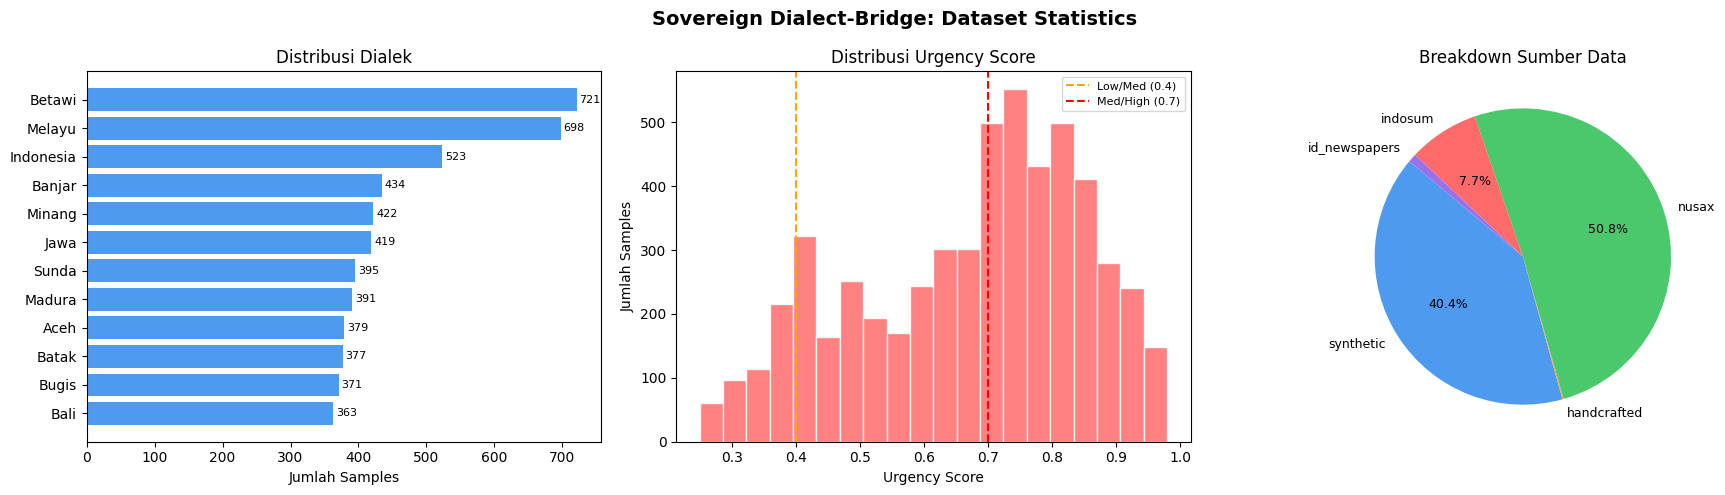

Chart saved: dataset_stats.png

Total samples  : 5,493
  Low  (<0.4) : 487 (8.9%)
  Med (0.4-0.7): 2,040 (37.1%)
  High (>0.7) : 2,966 (54.0%)

Top 10 instansi:
  Dinas Pekerjaan Umum                              : 694
  BPBD / Dinas Pekerjaan Umum                       : 653
  Kelurahan / Kecamatan                             : 388
  Dinas Kesehatan                                   : 335
  Dinas Lingkungan Hidup / KLHK                     : 335
  Polri / Satpol PP                                 : 331
  Dinas Kesehatan / BKKBN                           : 325
  Dinas Lingkungan Hidup                            : 323
  Dinas Sosial                                      : 319
  Dinas Pendidikan                                  : 319


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Sovereign Dialect-Bridge: Dataset Statistics", fontsize=14, fontweight="bold")

# 1. Dialect distribution
ax1 = axes[0]
dialect_items = sorted(dialect_counts.items(), key=lambda x: -x[1])
dialects, d_counts = zip(*dialect_items)
bars = ax1.barh(dialects, d_counts, color="#4E9AEF")
ax1.set_xlabel("Jumlah Samples")
ax1.set_title("Distribusi Dialek")
ax1.bar_label(bars, padding=2, fontsize=8)
ax1.invert_yaxis()

# 2. Urgency distribution
ax2 = axes[1]
urgencies = [r["urgency_score"] for r in unique_data]
n_bins = 20
ax2.hist(urgencies, bins=n_bins, color="#FF6B6B", edgecolor="white", alpha=0.85)
ax2.axvline(0.4, color="orange", linestyle="--", label="Low/Med (0.4)")
ax2.axvline(0.7, color="red",    linestyle="--", label="Med/High (0.7)")
ax2.set_xlabel("Urgency Score")
ax2.set_ylabel("Jumlah Samples")
ax2.set_title("Distribusi Urgency Score")
ax2.legend(fontsize=8)

# 3. Source breakdown pie
ax3 = axes[2]
src_labels = [k for k, v in SOURCE_STATS.items() if v > 0]
src_sizes  = [v for v in SOURCE_STATS.values() if v > 0]
colors     = ["#4E9AEF", "#FF9F40", "#4BC86B", "#FF6B6B", "#9B71EA", "#FFCE56", "#36A2EB"]
wedges, texts, autotexts = ax3.pie(
    src_sizes, labels=src_labels,
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    colors=colors[:len(src_labels)], startangle=140,
    textprops={"fontsize": 9},
)
ax3.set_title("Breakdown Sumber Data")

plt.tight_layout()
plot_path = CONFIG["output_dir"] / "dataset_stats.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved: {plot_path}")

# Text summary
total = len(unique_data)
urgency_low    = sum(1 for u in urgencies if u < 0.4)
urgency_medium = sum(1 for u in urgencies if 0.4 <= u < 0.7)
urgency_high   = sum(1 for u in urgencies if u >= 0.7)
print(f"\nTotal samples  : {total:,}")
print(f"  Low  (<0.4) : {urgency_low:,} ({urgency_low/total*100:.1f}%)")
print(f"  Med (0.4-0.7): {urgency_medium:,} ({urgency_medium/total*100:.1f}%)")
print(f"  High (>0.7) : {urgency_high:,} ({urgency_high/total*100:.1f}%)")

agency_counts = Counter(r["target_agency"] for r in unique_data)
print("\nTop 10 instansi:")
for agency, cnt in agency_counts.most_common(10):
    print(f"  {agency[:50]:50s}: {cnt}")

## Cell 19 · Simpan ke JSONL

In [20]:
total = len(unique_data)


def stratified_split(records, train_ratio: float, val_ratio: float, seed: int = 42):
    rng = random.Random(seed)
    grouped = defaultdict(list)
    for rec in records:
        grouped[rec["dialect"]].append(rec)

    train_split, val_split, test_split = [], [], []

    for dialect, items in grouped.items():
        rng.shuffle(items)
        n = len(items)

        n_train = int(round(n * train_ratio))
        n_val = int(round(n * val_ratio))

        if n >= 3:
            n_train = max(1, min(n_train, n - 2))
            n_val = max(1, min(n_val, n - n_train - 1))
        elif n == 2:
            n_train, n_val = 1, 0
        else:
            n_train, n_val = 1, 0

        train_items = items[:n_train]
        val_items = items[n_train:n_train + n_val]
        test_items = items[n_train + n_val:]

        train_split.extend(train_items)
        val_split.extend(val_items)
        test_split.extend(test_items)

    rng.shuffle(train_split)
    rng.shuffle(val_split)
    rng.shuffle(test_split)

    return {
        "train_data": train_split,
        "val_data": val_split,
        "test_data": test_split,
    }


if CONFIG.get("use_stratified_split", True):
    SPLITS = stratified_split(
        unique_data,
        train_ratio=CONFIG["train_ratio"],
        val_ratio=CONFIG["val_ratio"],
        seed=CONFIG["seed"],
    )
else:
    n_train = int(total * CONFIG["train_ratio"])
    n_val = int(total * CONFIG["val_ratio"])
    SPLITS = {
        "train_data": unique_data[:n_train],
        "val_data": unique_data[n_train:n_train + n_val],
        "test_data": unique_data[n_train + n_val:],
    }

for name, split_data in SPLITS.items():
    path = CONFIG["output_dir"] / f"{name}.jsonl"
    with open(path, "w", encoding="utf-8") as f:
        for record in split_data:
            f.write(json.dumps(record, ensure_ascii=False) + "\n")
    print(f"  Saved: {path.name} — {len(split_data)} records")

split_dialect_distribution = {
    name: dict(Counter(r["dialect"] for r in split_data).most_common())
    for name, split_data in SPLITS.items()
}
split_agency_distribution = {
    name: dict(Counter(r["target_agency"] for r in split_data).most_common())
    for name, split_data in SPLITS.items()
}

# Simpan metadata lengkap
metadata = {
    "total_samples": total,
    "train_samples": len(SPLITS["train_data"]),
    "val_samples": len(SPLITS["val_data"]),
    "test_samples": len(SPLITS["test_data"]),
    "schema_fields": sorted(REQUIRED_FIELDS),
    "schema_valid": len(schema_errors) == 0,
    "pii_remaining": len(pii_found),
    "duplicates_removed": duplicates_removed,
    "sources": SOURCE_STATS,
    "dialect_distribution": dict(dialect_counts.most_common()),
    "agency_distribution": dict(agency_counts.most_common()),
    "split_dialect_distribution": split_dialect_distribution,
    "split_agency_distribution": split_agency_distribution,
    "rebalance_config": {
        "dialect_max_per_dialect": CONFIG["rebalance_max_per_dialect"],
        "dialect_indonesia_max": CONFIG["rebalance_indonesia_max"],
        "agency_enabled": CONFIG.get("rebalance_agency_enabled", False),
        "agency_max_per_label": CONFIG.get("rebalance_agency_max_per_label"),
        "agency_min_per_label": CONFIG.get("rebalance_agency_min_per_label"),
        "agency_upsample": CONFIG.get("rebalance_agency_upsample", False),
        "agency_target_total": CONFIG.get("rebalance_agency_target_total"),
    },
    "urgency_distribution": {
        "low_<0.4": urgency_low,
        "medium_0.4-0.7": urgency_medium,
        "high_>0.7": urgency_high,
    },
    "top_agencies": dict(agency_counts.most_common(10)),
    "synthetic_styles": STRUCTURAL_STYLES,
}

stats_path = CONFIG["output_dir"] / "data_stats.json"
with open(stats_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"  Saved: {stats_path.name}")
print()
print("=" * 55)
total_target = 10000
status = "TARGET TERCAPAI" if total >= total_target else f"{total:,} ({total/total_target*100:.0f}% dari target)"
print(f"  {status}")
print(f"  Total: {total:,} samples")
print(f"  Train: {len(SPLITS['train_data']):,} | Val: {len(SPLITS['val_data']):,} | Test: {len(SPLITS['test_data']):,}")
print("=" * 55)
print("\nDataset siap untuk fine-tuning!")

  Saved: train_data.jsonl — 3845 records
  Saved: val_data.jsonl — 824 records
  Saved: test_data.jsonl — 824 records
  Saved: data_stats.json

  5,493 (55% dari target)
  Total: 5,493 samples
  Train: 3,845 | Val: 824 | Test: 824

Dataset siap untuk fine-tuning!
